# Data Analysis and Predictive Modeling for E-commerce
### Ocheme Charisa Final Project — Late Delivery Prediction

## 1. Imports and Setup

In [81]:
# ============================================
# Import Required Libraries
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Display and Visualization Settings
# ============================================
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# ============================================
# Random Seed for Reproducibility
# ============================================
random_state = 42

## 2. Load Datasets

In [82]:
path = "../data/"

customers   = pd.read_csv(path + "olist_customers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments    = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews     = pd.read_csv(path + "olist_order_reviews_dataset.csv")
orders      = pd.read_csv(path + "olist_orders_dataset.csv")
products    = pd.read_csv(path + "olist_products_dataset.csv")
sellers     = pd.read_csv(path + "olist_sellers_dataset.csv")

datasets = {
    "customers": customers, "geolocation": geolocation, "order_items": order_items,
    "payments": payments, "reviews": reviews, "orders": orders,
    "products": products, "sellers": sellers
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 10)
sellers: (3095, 4)


In [83]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_category_name(english version)',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

## 3. Merge Datasets into a Master Dataframe

In [84]:
# Backbone: orders + order items
Ecommerce = orders.merge(order_items, on='order_id', how='left')

# Product info (category name + English translation already included)
Ecommerce = Ecommerce.merge(products, on='product_id', how='left')

# Seller info
Ecommerce = Ecommerce.merge(sellers, on='seller_id', how='left')

# Customer info
Ecommerce = Ecommerce.merge(customers, on='customer_id', how='left')

# Payments — aggregate first since an order can have multiple payment rows
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).reset_index()
Ecommerce = Ecommerce.merge(payments_agg, on='order_id', how='left')

# Reviews — keep the most recent review per order
reviews_dedup = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')
Ecommerce = Ecommerce.merge(
    reviews_dedup[['order_id', 'review_score', 'review_comment_message']],
    on='order_id', how='left'
)

print(Ecommerce.shape)
Ecommerce.head()

(113425, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name(english version),product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,automotive,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,5.0,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,credit_card,5.0,NaN


In [85]:
orders_without_items = ~orders['order_id'].isin(order_items['order_id'])
print("Orders with no matching item rows:", orders_without_items.sum())

Orders with no matching item rows: 775


In [86]:
print(orders.loc[orders_without_items, 'order_status'].value_counts())

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


## 4. Data Quality Checks and Cleaning

# 4.1 
* Data Types
  

In [87]:
Ecommerce.dtypes

order_id                                   object
customer_id                                object
order_status                               object
order_purchase_timestamp                   object
order_approved_at                          object
order_delivered_carrier_date               object
order_delivered_customer_date              object
order_estimated_delivery_date              object
order_item_id                             float64
product_id                                 object
seller_id                                  object
shipping_limit_date                        object
price                                     float64
freight_value                             float64
product_category_name                      object
product_category_name(english version)     object
product_name_lenght                       float64
product_description_lenght                float64
product_photos_qty                        float64
product_weight_g                          float64


### 4.2 Duplicate Rows

In [88]:
print("Fully duplicate rows:", Ecommerce.duplicated().sum())

Fully duplicate rows: 0


### 4.3 Missing Values

In [89]:
missing = Ecommerce.isnull().sum()
missing_pct = (missing / len(Ecommerce)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
review_comment_message,65501,57.748292
order_delivered_customer_date,3229,2.846815
product_category_name,2378,2.096540
product_description_lenght,2378,2.096540
product_name_lenght,2378,2.096540
product_category_name(english version),2378,2.096540
product_photos_qty,2378,2.096540
order_delivered_carrier_date,1968,1.735067
review_score,961,0.847256
product_height_cm,793,0.699140


### 4.4 Remove Orders With No Line Items

775 orders (mostly `unavailable` and `canceled` status) have no matching rows in `order_items`, and therefore no delivery outcome. Since our target is late delivery, these rows carry no usable label and are removed here.

In [90]:
before = Ecommerce.shape[0]
Ecommerce = Ecommerce[Ecommerce['order_id'].isin(order_items['order_id'])].reset_index(drop=True)
after = Ecommerce.shape[0]
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")

Rows before: 113425 | Rows after: 112650 | Removed: 775


### 4.5 Date Columns — Convert to Datetime

In [91]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date'
]
for col in date_cols:
    Ecommerce[col] = pd.to_datetime(Ecommerce[col], errors='coerce')

Ecommerce[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object

### 4.6 Outlier Check — Price, Freight, and Product Dimensions

In [92]:
numeric_cols = ['price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
Ecommerce[numeric_cols].describe()

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,120.653739,19.990320,2093.672047,30.153669,16.593766,22.996546
std,183.633928,15.806405,3751.596884,16.153449,13.443483,11.707268
min,0.850000,0.000000,0.000000,7.000000,2.000000,6.000000
25%,39.900000,13.080000,300.000000,18.000000,8.000000,15.000000
50%,74.990000,16.260000,700.000000,25.000000,13.000000,20.000000
75%,134.900000,21.150000,1800.000000,38.000000,20.000000,30.000000
max,6735.000000,409.680000,40425.000000,105.000000,105.000000,118.000000


### 4.7 Rename Awkward Category Column

In [93]:
Ecommerce.rename(columns={'product_category_name(english version)': 'product_category_name_english'}, inplace=True)

### 4.8 Recheck Missing Values After Removing Orphan Orders

In [94]:
missing = Ecommerce.isnull().sum()
missing_pct = (missing / len(Ecommerce)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
review_comment_message,65249,57.921882
order_delivered_customer_date,2454,2.178429
product_category_name,1603,1.422992
product_category_name_english,1603,1.422992
product_name_lenght,1603,1.422992
product_description_lenght,1603,1.422992
product_photos_qty,1603,1.422992
order_delivered_carrier_date,1194,1.059920
review_score,942,0.836218
product_width_cm,18,0.015979


### 4.9 Investigate Orders Missing a Delivered Date

In [95]:
Ecommerce.loc[Ecommerce['order_delivered_customer_date'].isnull(), 'order_status'].value_counts()

order_status
shipped        1185
canceled        535
invoiced        359
processing      357
delivered         8
unavailable       7
approved          3
Name: count, dtype: int64

### 4.10 Check Zero-Weight Products

In [96]:
print("Products with 0 weight:", (Ecommerce['product_weight_g'] == 0).sum())

Products with 0 weight: 8


### 4.11 Standardize Zero Product Weight as Missing

In [97]:
Ecommerce.loc[Ecommerce['product_weight_g'] == 0, 'product_weight_g'] = np.nan
print("Remaining missing weight values:", Ecommerce['product_weight_g'].isnull().sum())

Remaining missing weight values: 26


### 4.12 Remove Orders With No Delivery Date (No Valid Target Label)

2,454 orders have no `order_delivered_customer_date`, including 8 inconsistent rows marked `delivered` with no date recorded. None can be reliably labeled late or on-time, so they are removed here.

In [98]:
before = Ecommerce.shape[0]
Ecommerce = Ecommerce[Ecommerce['order_delivered_customer_date'].notnull()].reset_index(drop=True)
after = Ecommerce.shape[0]
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")

Rows before: 112650 | Rows after: 110196 | Removed: 2454


### 4.13 Recheck Missing Values

In [99]:
missing = Ecommerce.isnull().sum()
missing_pct = (missing / len(Ecommerce)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
review_comment_message,64295,58.346038
product_category_name,1537,1.394787
product_category_name_english,1537,1.394787
product_name_lenght,1537,1.394787
product_description_lenght,1537,1.394787
product_photos_qty,1537,1.394787
review_score,827,0.750481
product_weight_g,26,0.023594
product_length_cm,18,0.016335
product_height_cm,18,0.016335


## 5. Engineer the Prediction Target: is_late

### 5.1 Confirm Estimated Delivery Date Has No Gaps

In [100]:
print("Missing order_estimated_delivery_date:", Ecommerce['order_estimated_delivery_date'].isnull().sum())

Missing order_estimated_delivery_date: 0


### 5.2 Create the Target Column

An order is labeled late (1) if it was delivered after the estimated delivery date, and on-time (0) otherwise.

In [101]:
Ecommerce['is_late'] = (Ecommerce['order_delivered_customer_date'] > Ecommerce['order_estimated_delivery_date']).astype(int)
Ecommerce['is_late'].value_counts()

is_late
0    101481
1      8715
Name: count, dtype: int64

### 5.3 Check Class Balance

is_late
0    92.091364
1     7.908636
Name: proportion, dtype: float64


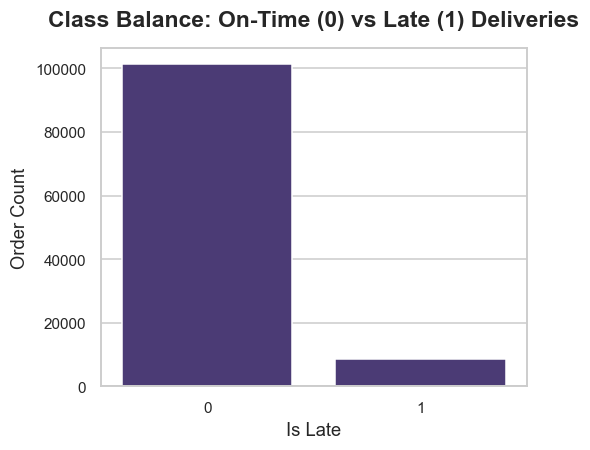

In [102]:
balance = Ecommerce['is_late'].value_counts(normalize=True) * 100
print(balance)

plt.figure(figsize=(5,4))
sns.countplot(x='is_late', data=Ecommerce)
plt.title('Class Balance: On-Time (0) vs Late (1) Deliveries')
plt.xlabel('Is Late')
plt.ylabel('Order Count')
plt.show()

### 6.0 Plot Style Defaults

In [103]:
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 110,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

def annotate_bars(ax, fmt='{:.0f}'):
    """Adds value labels above each bar for readability."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=10)

### 6.1 Average Time Between Purchase and Delivery

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64


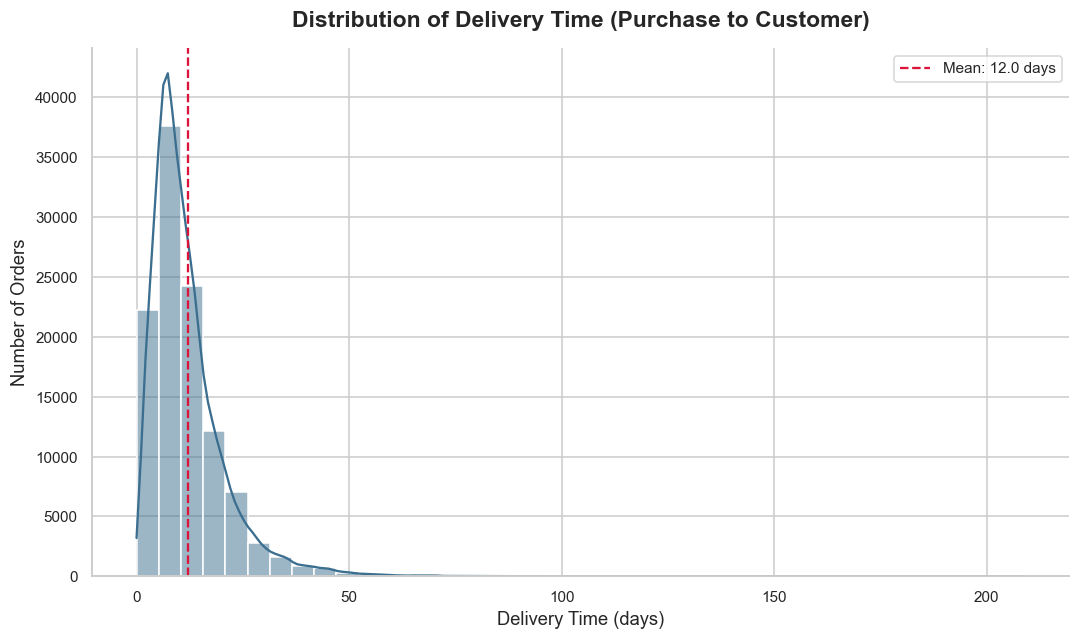

In [104]:
Ecommerce['delivery_time_days'] = (Ecommerce['order_delivered_customer_date'] - Ecommerce['order_purchase_timestamp']).dt.days

print(Ecommerce['delivery_time_days'].describe())

fig, ax = plt.subplots()
sns.histplot(Ecommerce['delivery_time_days'], bins=40, kde=True, ax=ax, color='#3b6e8f')
mean_val = Ecommerce['delivery_time_days'].mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f} days')
ax.set_title('Distribution of Delivery Time (Purchase to Customer)')
ax.set_xlabel('Delivery Time (days)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Average delivery time is 12.0 days (median 10 days), with 75% of orders delivered within 15 days. The distribution is heavily right-skewed — a long tail stretches out to 209 days, meaning a small subset of orders experience extreme delays far beyond the norm. Since the mean sits above the median, these outliers are pulling the average upward rather than reflecting typical performance.

**Recommendation:** Using the standard IQR method (Q3 + 1.5×IQR ≈ 15 + 13.5 = 28.5 days), orders taking longer than ~29 days should be flagged as outliers for special handling during modeling, rather than treated as ordinary variation. Operationally, these extreme cases are worth investigating separately, as they likely stem from specific logistics failures rather than routine delivery variance.

### 6.2 Average Shipping Delay (Actual vs Estimated Delivery)

count    110196.000000
mean        -12.030201
std          10.160157
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: shipping_delay_days, dtype: float64


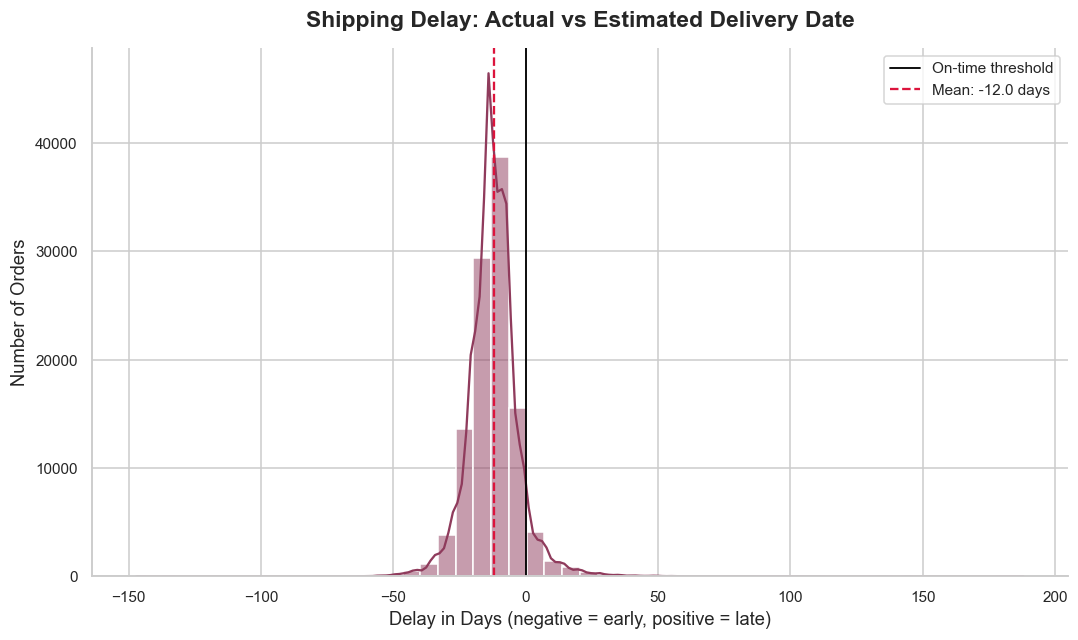

In [105]:
Ecommerce['shipping_delay_days'] = (Ecommerce['order_delivered_customer_date'] - Ecommerce['order_estimated_delivery_date']).dt.days

print(Ecommerce['shipping_delay_days'].describe())

fig, ax = plt.subplots()
sns.histplot(Ecommerce['shipping_delay_days'], bins=50, kde=True, ax=ax, color='#8f3b5c')
ax.axvline(0, color='black', linestyle='-', linewidth=1.2, label='On-time threshold')
mean_val = Ecommerce['shipping_delay_days'].mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f} days')
ax.set_title('Shipping Delay: Actual vs Estimated Delivery Date')
ax.set_xlabel('Delay in Days (negative = early, positive = late)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

On average, orders arrive 12 days *earlier* than their estimated delivery date (mean: -12.0, median: -13.0), meaning Olist's delivery estimates are consistently conservative — the platform under-promises and over-delivers on timing. However, the distribution has a real right tail: some orders arrive up to 188 days *after* their estimate, and these represent the population most likely to drive customer dissatisfaction — exactly what the `is_late` target is designed to capture.

**Recommendation:** Because estimated delivery windows are padded by roughly 12 days on average, Olist could tighten its estimates to appear more competitive without materially hurting on-time performance. Separately, the late-tail orders deserve root-cause investigation (which sellers, regions, or categories they cluster around) since fixing these drives the most customer-experience value.

### 6.3 Time Breakdown of Each Order Stage

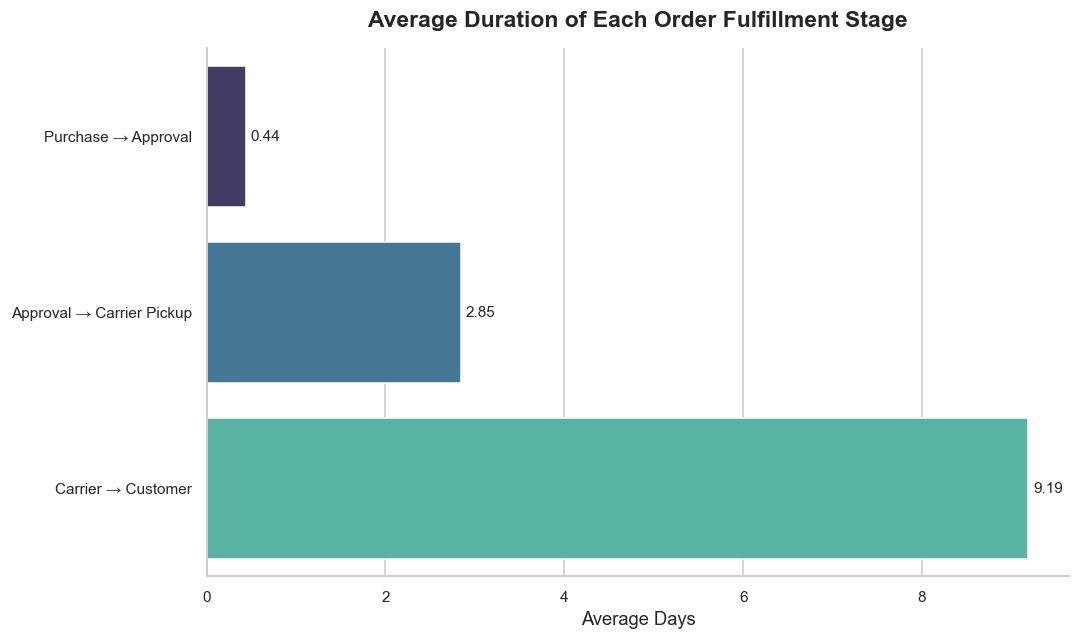

In [106]:
Ecommerce['approval_time_days'] = (Ecommerce['order_approved_at'] - Ecommerce['order_purchase_timestamp']).dt.total_seconds() / 86400
Ecommerce['carrier_pickup_days'] = (Ecommerce['order_delivered_carrier_date'] - Ecommerce['order_approved_at']).dt.total_seconds() / 86400
Ecommerce['transit_days'] = (Ecommerce['order_delivered_customer_date'] - Ecommerce['order_delivered_carrier_date']).dt.total_seconds() / 86400

stage_means = pd.Series({
    'Purchase → Approval': Ecommerce['approval_time_days'].mean(),
    'Approval → Carrier Pickup': Ecommerce['carrier_pickup_days'].mean(),
    'Carrier → Customer': Ecommerce['transit_days'].mean()
})

fig, ax = plt.subplots()
sns.barplot(x=stage_means.values, y=stage_means.index, hue=stage_means.index, palette='mako', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.2f}')
ax.set_title('Average Duration of Each Order Fulfillment Stage')
ax.set_xlabel('Average Days')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Payment approval is fast and not a bottleneck (0.44 days on average). The two logistics stages dominate total delivery time: seller-to-carrier handoff takes 2.85 days, and carrier-to-customer transit takes 9.19 days — the latter alone accounts for roughly 76% of the average 12-day delivery time.

**Recommendation:** Efforts to reduce late deliveries should focus on carrier/last-mile logistics, not payment processing, since that's where the overwhelming majority of time — and delay risk — accumulates. This also signals that shipping-related features (seller state, customer state, freight value as a distance proxy) are likely to be strong predictors in the model.

### 6.4 Orders per Month

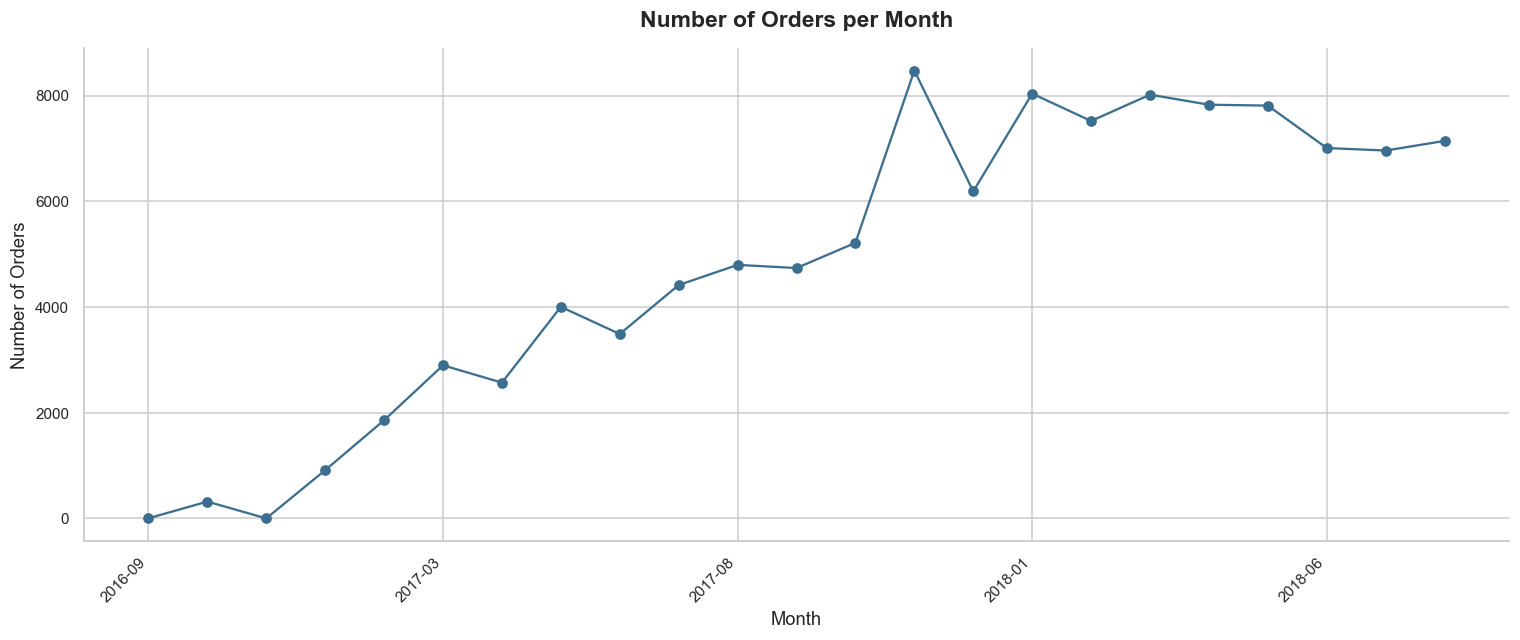

In [107]:
Ecommerce['order_month'] = Ecommerce['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_orders = Ecommerce.groupby('order_month').size()

fig, ax = plt.subplots(figsize=(14, 6))
monthly_orders.plot(kind='line', marker='o', ax=ax, color='#3b6e8f')
ax.set_title('Number of Orders per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Order volume shows strong platform growth: near-zero in September–November 2016 (Olist's launch period), followed by a steady, roughly linear climb through 2017. A sharp spike appears around November 2017 — consistent with Black Friday — pushing volume to its highest point in the dataset (~8,500 orders), before dropping back in December 2017. From early 2018 onward, volume stabilizes into a mature plateau of roughly 7,000–8,000 orders/month.

**Recommendation:** The November spike is operationally significant beyond just sales — a sudden ~60% volume surge likely strains carrier capacity, which may correlate with a higher late-delivery rate that month. This is worth testing directly as a feature later (e.g., an `is_peak_month` or order-volume-that-week feature) since it ties order timing directly to your `is_late` target, not just to revenue.

### 6.5 Seasonality in Order Volume

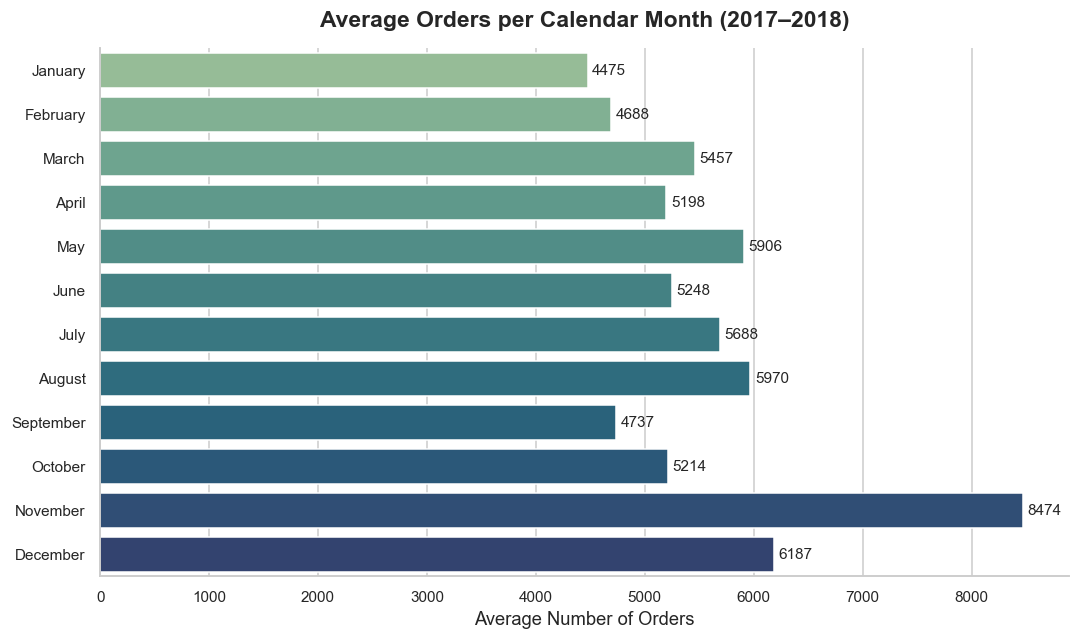

In [108]:
seasonal_df = Ecommerce[Ecommerce['order_purchase_timestamp'].dt.year >= 2017].copy()
seasonal_df['order_year'] = seasonal_df['order_purchase_timestamp'].dt.year
seasonal_df['order_month_name'] = seasonal_df['order_purchase_timestamp'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

year_month_counts = seasonal_df.groupby(['order_year', 'order_month_name']).size().reset_index(name='order_count')
seasonal_avg = year_month_counts.groupby('order_month_name')['order_count'].mean().reindex(month_order)

fig, ax = plt.subplots()
sns.barplot(x=seasonal_avg.values, y=seasonal_avg.index, hue=seasonal_avg.index, palette='crest', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.0f}')
ax.set_title('Average Orders per Calendar Month (2017–2018)')
ax.set_xlabel('Average Number of Orders')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Once corrected to a per-year average (rather than a raw sum distorted by unequal year coverage), a clear seasonal pattern emerges. **November stands out sharply** at ~8,474 average orders — about 42% higher than the next-busiest month (August, ~5,970) — confirming the Black Friday effect seen in 6.4 is a genuine seasonal spike, not a one-off. December stays elevated (~6,187), while January and February are the quietest months (~4,475–4,688), consistent with a post-holiday spending lull.

**Recommendation:** Olist should plan for a structural November demand surge every year (extra carrier capacity, seller stock readiness) rather than treating it as a one-time anomaly. For the modeling stage, this also supports engineering a `holiday_season` or `is_november` feature — a period with sharply higher order volume plausibly experiences more late deliveries due to logistics strain, making it a strong candidate predictor for `is_late`.

### 6.6 Top 5 Customers by Number of Purchases

8d50f5ea...    15
3e43e610...     9
ca77025e...     7
1b6c7548...     7
6469f99c...     7
Name: order_id, dtype: int64


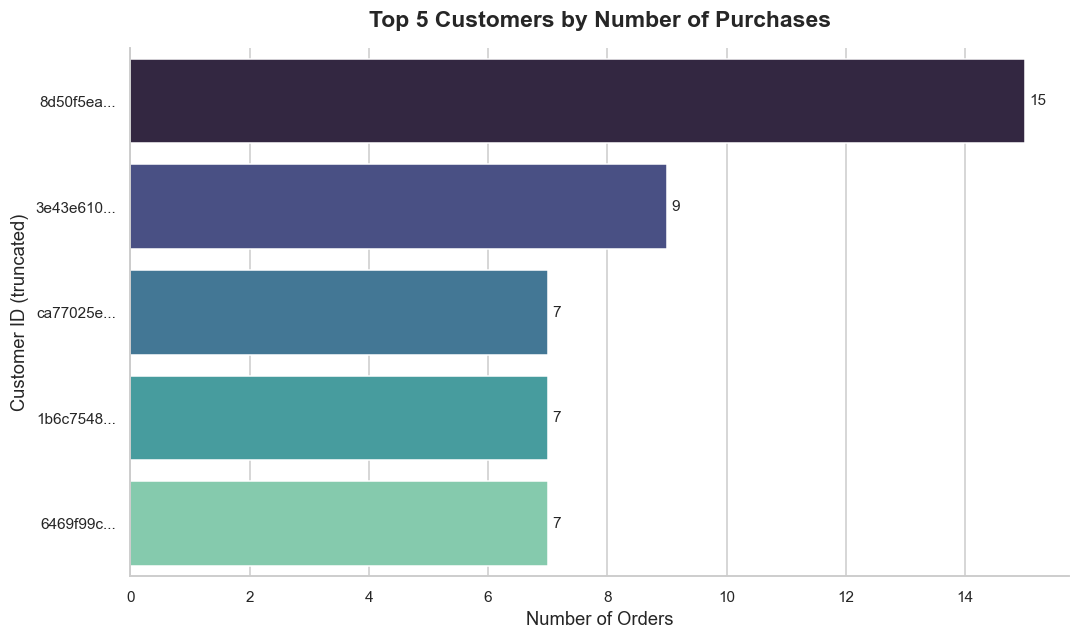

In [109]:
top_customers = Ecommerce.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False).head(5)
top_customers.index = [cid[:8] + '...' for cid in top_customers.index]  # truncate hashed IDs for readability

print(top_customers)

fig, ax = plt.subplots()
sns.barplot(x=top_customers.values, y=top_customers.index, hue=top_customers.index, palette='mako', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.0f}')
ax.set_title('Top 5 Customers by Number of Purchases')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Customer ID (truncated)')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

The most frequent customer placed 15 orders, followed by a cluster around 7–9 orders for the next four. Given that (per 6.7) the overwhelming majority of customers purchase only once, a customer reaching 15 separate orders is a significant outlier relative to typical behavior on this platform.

**Recommendation:** This top customer is worth a closer look — such high frequency is unusual for an individual consumer marketplace and could indicate a small business or reseller account rather than typical retail behavior. This doesn't change the modeling approach, but it's a good observation to mention in the report as a nuance in "customer" behavior on the platform.

### 6.7 One-Time vs Returning Customers

One-Time     90555
Returning     2801
Name: count, dtype: int64
One-Time     97.0
Returning     3.0
Name: proportion, dtype: float64


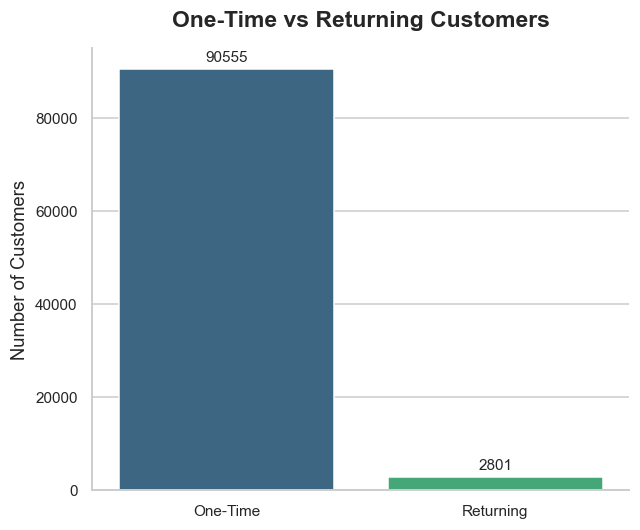

In [110]:
orders_per_customer = Ecommerce.groupby('customer_unique_id')['order_id'].nunique()
customer_type = pd.Series(np.where(orders_per_customer > 1, 'Returning', 'One-Time'))

type_counts = customer_type.value_counts()
type_pct = customer_type.value_counts(normalize=True) * 100
print(type_counts)
print(type_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='viridis', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.0f}')
ax.set_title('One-Time vs Returning Customers')
ax.set_xlabel('')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Only 3.0% of customers (2,801 of 93,356) made more than one purchase; 97.0% are one-time buyers. This is a strikingly low repeat-purchase rate. One caveat worth noting: the dataset covers roughly two years, so some "one-time" customers — especially those who purchased near the end of the observation window — simply may not have had enough time to reorder yet. The true repeat rate could be modestly understated for that reason.

**Recommendation:** With such a small returning-customer base, customer-level repurchase history is unlikely to be a strong, reliable feature for predicting late delivery (too sparse to generalize). It's more useful as a separate business insight: Olist's growth is overwhelmingly driven by new-customer acquisition rather than retention, which is a relevant strategic point for the recommendations section of your report.

### 6.8 Top 5 Sellers by Sales Revenue

4869f7a5...    226987.93
53243585...    217940.44
4a3ca931...    196882.12
fa1c13f2...    190917.14
7c67e144...    186570.05
Name: price, dtype: float64


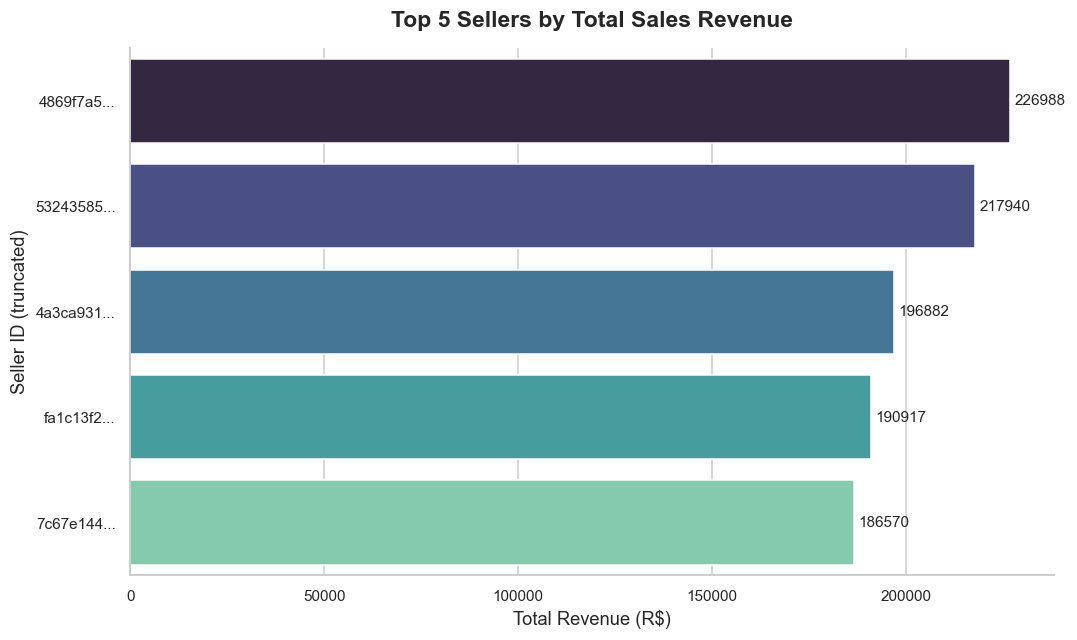

In [111]:
top_sellers = Ecommerce.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(5)
top_sellers.index = [sid[:8] + '...' for sid in top_sellers.index]

print(top_sellers.round(2))

fig, ax = plt.subplots()
sns.barplot(x=top_sellers.values, y=top_sellers.index, hue=top_sellers.index, palette='mako', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.0f}')
ax.set_title('Top 5 Sellers by Total Sales Revenue')
ax.set_xlabel('Total Revenue (R$)')
ax.set_ylabel('Seller ID (truncated)')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Revenue among the top 5 sellers is tightly clustered — from R$226,988 down to R$186,570, less than a 22% spread across the whole group, rather than one dominant seller towering over the rest. This suggests a reasonably healthy, non-monopolized marketplace at the top end.

**Recommendation:** Because these five sellers each represent a large concentration of orders, any delivery issue on their end affects a disproportionate number of customers. It's worth checking (as a follow-up, time permitting) whether these top sellers have above- or below-average late-delivery rates — if one of them is a delivery risk, it matters more than an average seller would.

### 6.9 Distribution of Payment Types

payment_type
credit_card    84154
boleto         22362
voucher         2026
debit_card      1651
Name: count, dtype: int64
payment_type
credit_card    76.37
boleto         20.29
voucher         1.84
debit_card      1.50
Name: proportion, dtype: float64


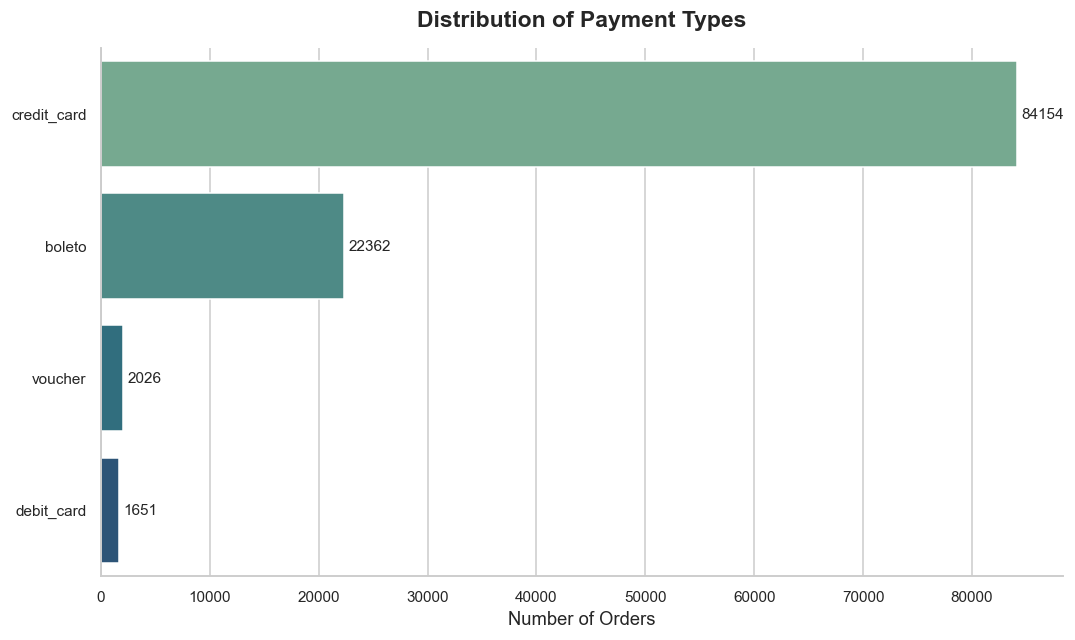

In [112]:
payment_dist = Ecommerce['payment_type'].value_counts()
payment_pct = Ecommerce['payment_type'].value_counts(normalize=True) * 100
print(payment_dist)
print(payment_pct.round(2))

fig, ax = plt.subplots()
sns.barplot(x=payment_dist.values, y=payment_dist.index, hue=payment_dist.index, palette='crest', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.0f}')
ax.set_title('Distribution of Payment Types')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Credit card dominates at 76.4% of orders, followed by boleto (Brazil's bank-slip payment method) at 20.3%. Debit card and voucher are marginal (1.5% and 1.8%).

**Recommendation:** Boleto is worth watching specifically for the late-delivery model — unlike instant credit card authorization, a boleto payment requires the customer to actually go pay the slip (often at a bank or lottery outlet), which can delay order approval by a day or more. This makes `payment_type` a reasonable candidate feature: orders paid by boleto may start their fulfillment clock later, increasing late-delivery risk independent of logistics.

### 6.10 Which Payment Type Has the Highest Average Payment Value

payment_type
credit_card    182.30
boleto         176.33
debit_card     149.20
voucher        121.00
Name: payment_value, dtype: float64


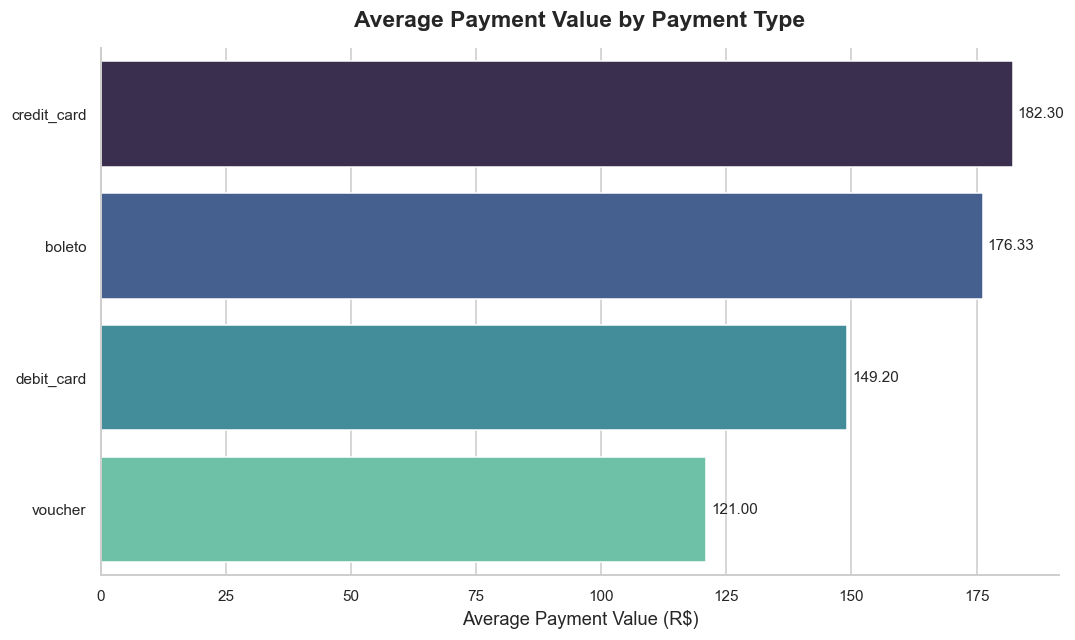

In [113]:
avg_payment = Ecommerce.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
print(avg_payment.round(2))

fig, ax = plt.subplots()
sns.barplot(x=avg_payment.values, y=avg_payment.index, hue=avg_payment.index, palette='mako', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.2f}')
ax.set_title('Average Payment Value by Payment Type')
ax.set_xlabel('Average Payment Value (R$)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Credit card also has the highest average order value (R$182.30), with boleto close behind (R$176.33). Debit card and voucher orders are smaller on average (R$149.20 and R$121.00).

**Recommendation:** This is primarily a business insight rather than a delivery-risk signal — higher-value orders skew toward credit card, so marketing/promotions aimed at increasing basket size could reasonably lean on credit card incentives. No strong action needed for the modeling pipeline here.

### 6.11 Product Categories with Highest and Lowest Review Scores

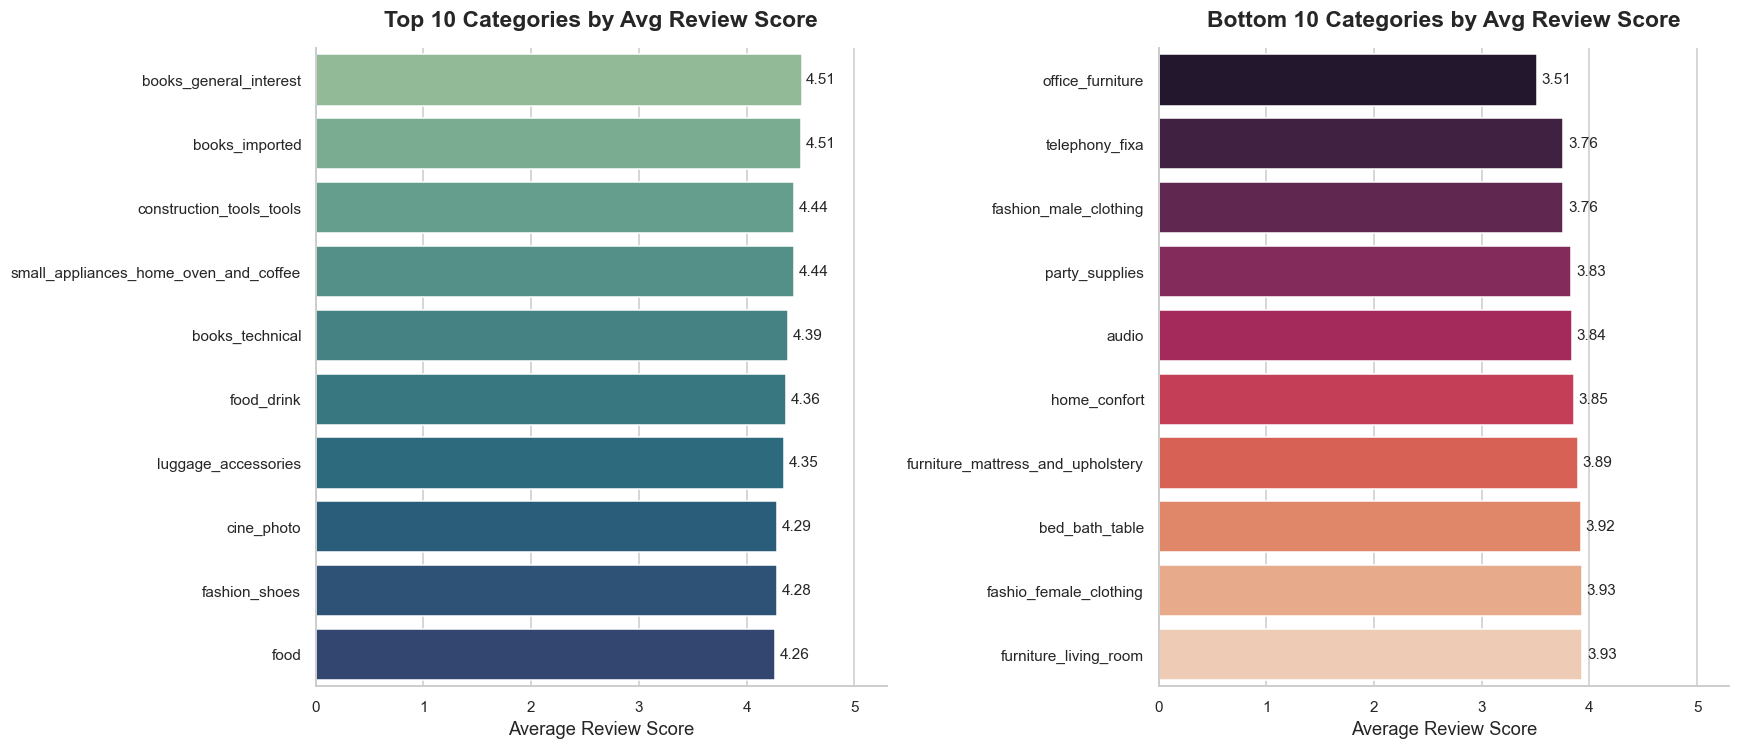

In [114]:
category_review = Ecommerce.groupby('product_category_name_english').agg(
    avg_review_score=('review_score', 'mean'),
    order_count=('order_id', 'nunique')
)
category_review = category_review[category_review['order_count'] >= 30]  # exclude low-volume, unstable averages

top10 = category_review.sort_values('avg_review_score', ascending=False).head(10)
bottom10 = category_review.sort_values('avg_review_score', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=top10['avg_review_score'], y=top10.index, hue=top10.index, palette='crest', legend=False, ax=axes[0])
annotate_bars(axes[0], fmt='{:.2f}')
axes[0].set_title('Top 10 Categories by Avg Review Score')
axes[0].set_xlabel('Average Review Score')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 5.3)

sns.barplot(x=bottom10['avg_review_score'], y=bottom10.index, hue=bottom10.index, palette='rocket', legend=False, ax=axes[1])
annotate_bars(axes[1], fmt='{:.2f}')
axes[1].set_title('Bottom 10 Categories by Avg Review Score')
axes[1].set_xlabel('Average Review Score')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 5.3)

plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Books dominate the top of the ratings table — books_general_interest and books_imported tie for the highest score (4.51), and books_technical also appears in the top 10 (4.39). luggage_accessories is the most statistically robust top performer, combining a strong score (4.35) with by far the largest sample size in the top 10 (1,019 orders).

At the bottom, office_furniture has the lowest average score (3.51) — and with 1,254 orders, this is a reliable signal, not sampling noise. More strikingly, furniture-related categories dominate the bottom of the list: office_furniture, furniture_mattress_and_upholstery, and furniture_living_room all appear in the bottom 10, and bed_bath_table (the single highest-volume category in the entire dataset at 9,272 orders) also lands here with a middling 3.92.

**Recommendation:** The clustering of furniture categories at the bottom is unlikely to be coincidental — bulky, heavy items are inherently harder to ship without delay or damage, which plausibly drives lower satisfaction. This directly supports using `product_category_name_english` (and/or product weight/dimensions as a bulkiness proxy) as a predictor for late delivery — the categories with review problems are exactly the ones likely to have fulfillment problems too.

### 6.12 Average Price and Freight Cost per Category (Top 15 by Order Volume)

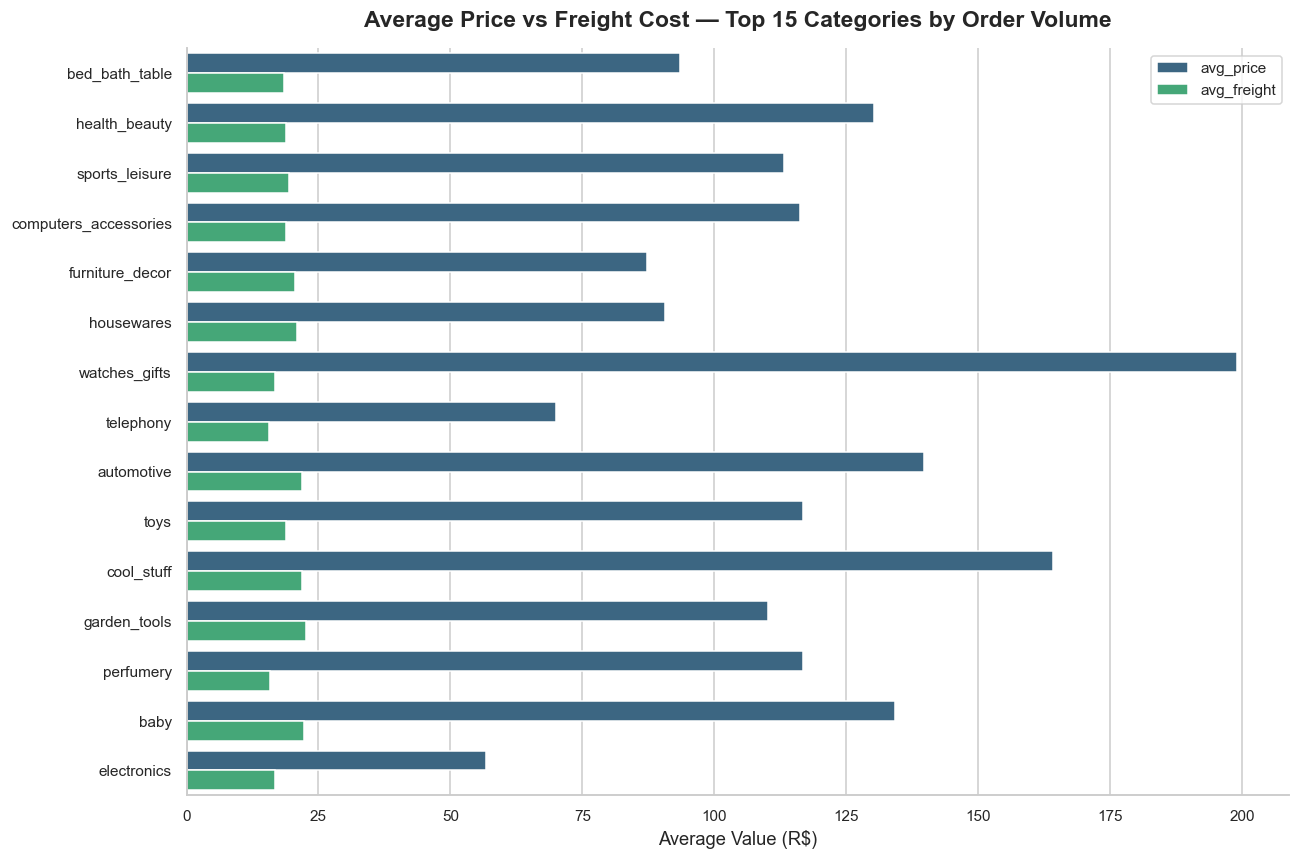

In [115]:
category_stats = Ecommerce.groupby('product_category_name_english').agg(
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    order_count=('order_id', 'nunique')
).sort_values('order_count', ascending=False).head(15)

plot_df = category_stats[['avg_price', 'avg_freight']].reset_index().melt(
    id_vars='product_category_name_english', var_name='Metric', value_name='Value'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=plot_df, x='Value', y='product_category_name_english', hue='Metric', palette='viridis', ax=ax)
ax.set_title('Average Price vs Freight Cost — Top 15 Categories by Order Volume')
ax.set_xlabel('Average Value (R$)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

Price and freight cost are clearly decoupled — high value does not mean high shipping cost. watches_gifts has the highest average price (R$199.06) among top categories, yet one of the lowest freight costs (R$16.75), since watches/gift items are typically small and light. Conversely, garden_tools has the highest average freight (R$22.65) despite only mid-range pricing (R$110.24), and baby (R$22.24 freight) follows a similar pattern — both are bulky product categories regardless of item value. electronics, despite being the cheapest category by average price (R$56.81), still carries a moderate freight cost similar to watches_gifts.

**Recommendation:** This confirms freight_value is functioning as a proxy for physical bulk/shipping distance rather than product value — meaning it's a genuinely independent, non-redundant feature for the late-delivery model (not just a restatement of price). Both `freight_value` and `price` are worth keeping as separate predictors rather than treating one as a stand-in for the other.

In [116]:
# Note: Bahia is a Brazilian STATE (capital Salvador), not a city — handled via customer_state.
# The other five are handled as cities via customer_city.

location_filters = {
    'Sao Paulo': Ecommerce['customer_city'].str.lower() == 'sao paulo',
    'Porto Alegre': Ecommerce['customer_city'].str.lower() == 'porto alegre',
    'Curitiba': Ecommerce['customer_city'].str.lower() == 'curitiba',
    'Fortaleza': Ecommerce['customer_city'].str.lower() == 'fortaleza',
    'Brasilia': Ecommerce['customer_city'].str.lower() == 'brasilia',
    'Bahia (state)': Ecommerce['customer_state'] == 'BA'
}

geo_summary = []
for location, mask in location_filters.items():
    subset = Ecommerce[mask]
    geo_summary.append({
        'location': location,
        'order_count': subset.shape[0],
        'avg_delivery_days': subset['delivery_time_days'].mean(),
        'late_rate_pct': subset['is_late'].mean() * 100
    })

geo_summary_df = pd.DataFrame(geo_summary).set_index('location')
print(geo_summary_df.round(2))

               order_count  avg_delivery_days  late_rate_pct
location                                                    
Sao Paulo            17402               7.56           6.22
Porto Alegre          1572              15.44          11.45
Curitiba              1727               9.93           4.86
Fortaleza              694              19.99          18.16
Brasilia              2341              12.51           7.48
Bahia (state)         3683              18.77          13.68


## 6.13 Geospatial Analysis (Selected Cities and Bahia State)

*Note: Bahia is a Brazilian state (capital Salvador), not a city — treated separately via customer_state, while the other five locations use customer_city.*

### 6.13.1 Delivery Performance by Location — Summary Table

### 6.13.2 Visual Comparison — Delivery Time and Late Rate by Location

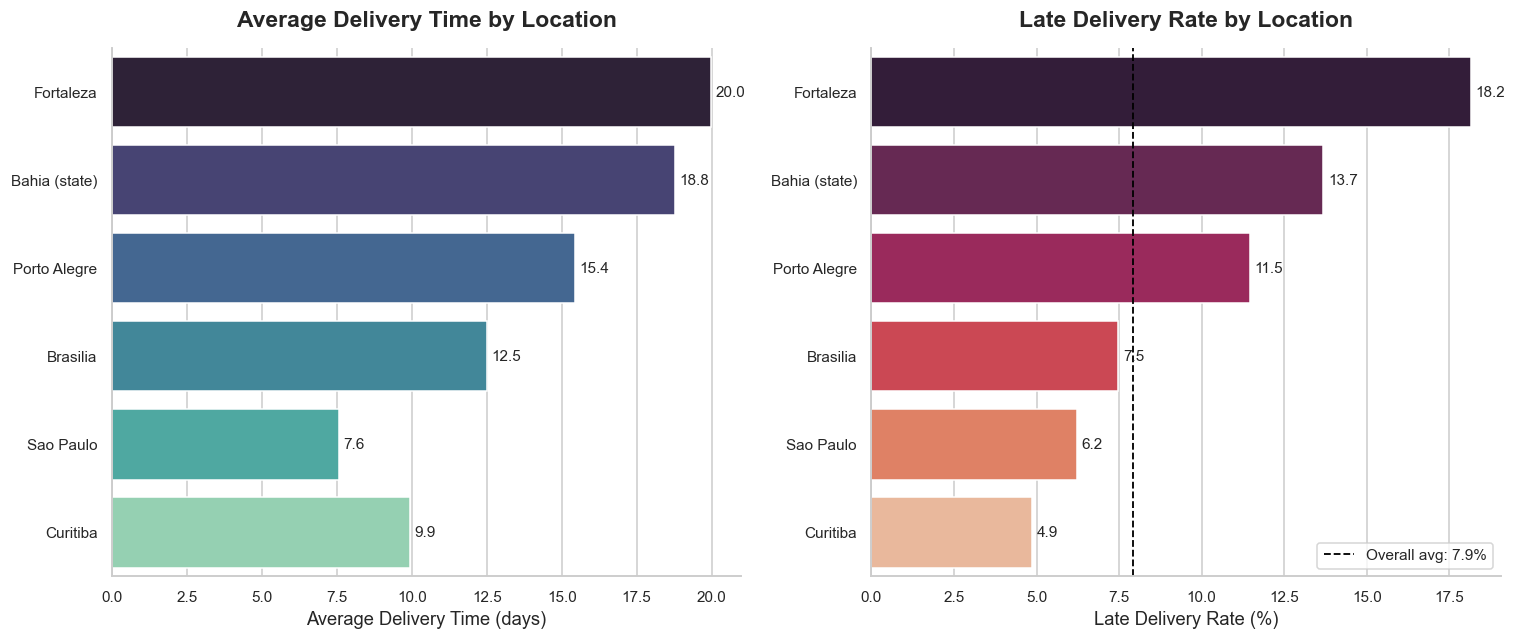

In [117]:
geo_sorted = geo_summary_df.sort_values('late_rate_pct', ascending=False)
overall_late_rate = Ecommerce['is_late'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=geo_sorted['avg_delivery_days'], y=geo_sorted.index, hue=geo_sorted.index, palette='mako', legend=False, ax=axes[0])
annotate_bars(axes[0], fmt='{:.1f}')
axes[0].set_title('Average Delivery Time by Location')
axes[0].set_xlabel('Average Delivery Time (days)')
axes[0].set_ylabel('')

sns.barplot(x=geo_sorted['late_rate_pct'], y=geo_sorted.index, hue=geo_sorted.index, palette='rocket', legend=False, ax=axes[1])
annotate_bars(axes[1], fmt='{:.1f}')
axes[1].axvline(overall_late_rate, color='black', linestyle='--', linewidth=1.2, label=f'Overall avg: {overall_late_rate:.1f}%')
axes[1].set_title('Late Delivery Rate by Location')
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.13.3 Geospatial Map — Order Volume and Late Rate by Location

               order_count  avg_delivery_days  late_rate_pct    lng    lat
location                                                                  
Sao Paulo            17402               7.56           6.22 -46.63 -23.57
Porto Alegre          1572              15.44          11.45 -51.19 -30.05
Curitiba              1727               9.93           4.86 -49.27 -25.45
Fortaleza              694              19.99          18.16 -38.53  -3.76
Brasilia              2341              12.51           7.48 -47.97 -15.81
Bahia (state)         3683              18.77          13.68 -39.56 -13.05


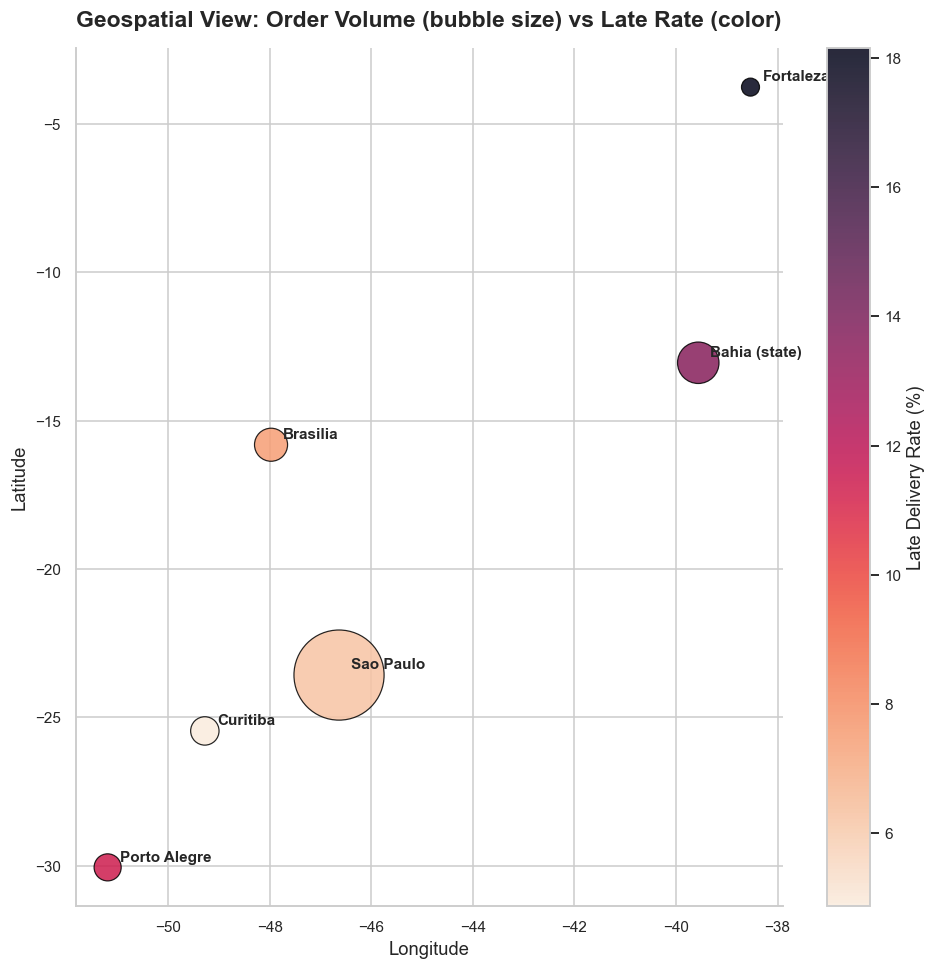

In [118]:
geo_coords = {}
for city in ['sao paulo', 'porto alegre', 'curitiba', 'fortaleza', 'brasilia']:
    match = geolocation[geolocation['geolocation_city'].str.lower() == city]
    geo_coords[city.title()] = (match['geolocation_lng'].mean(), match['geolocation_lat'].mean())

bahia_match = geolocation[geolocation['geolocation_state'] == 'BA']
geo_coords['Bahia (state)'] = (bahia_match['geolocation_lng'].mean(), bahia_match['geolocation_lat'].mean())

geo_plot_df = geo_summary_df.copy()
geo_plot_df['lng'] = [geo_coords[loc][0] for loc in geo_plot_df.index]
geo_plot_df['lat'] = [geo_coords[loc][1] for loc in geo_plot_df.index]
print(geo_plot_df.round(2))  # sanity check — lng/lat should not be NaN

fig, ax = plt.subplots(figsize=(9, 9))
scatter = ax.scatter(
    geo_plot_df['lng'], geo_plot_df['lat'],
    s=geo_plot_df['order_count'] / 5,
    c=geo_plot_df['late_rate_pct'],
    cmap='rocket_r', edgecolor='black', linewidth=0.8, alpha=0.85
)
for loc, row in geo_plot_df.iterrows():
    ax.annotate(loc, (row['lng'], row['lat']), textcoords="offset points", xytext=(8, 4), fontsize=10, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Late Delivery Rate (%)')
ax.set_title('Geospatial View: Order Volume (bubble size) vs Late Rate (color)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**Key Findings & Recommendations:**

A clear geographic pattern emerges, and it lines up consistently across all three views (table, bar charts, and map). Ranked by late delivery rate: **Fortaleza is the worst performer by a wide margin (18.2% late, ~20.0 day average delivery)** — more than double the platform-wide average of 7.9%. **Bahia state follows (13.7% late, 18.8 days)**, and **Porto Alegre is also above average (11.5% late)**. In contrast, **Curitiba has the lowest late rate of all six (4.9%)**, and **São Paulo — the platform's largest hub by far at 17,402 orders — combines high volume with a strong 6.2% late rate** and the second-fastest average delivery (7.6 days). Brasília sits close to the national average on both measures.

The geospatial map makes the underlying driver visually obvious: the two worst-performing locations (Fortaleza, Bahia) are both in Brazil's Northeast, geographically farthest from São Paulo — where Olist's seller base and logistics activity are heavily concentrated (visible in the bubble sizes alone). The best-performing locations (São Paulo, Curitiba) are both in the Southeast/South, close to that hub. This suggests physical shipping distance from the seller concentration, not city-specific issues, is the primary driver of late-delivery risk.

**Recommendation:** This is one of the strongest signals in the entire EDA. For modeling, a geography-based feature (customer state/region, or better, a computed seller-to-customer distance) is very likely to be one of the most predictive features for `is_late` — far more informative than city name alone. For the business, this points to a concrete operational recommendation: Olist should prioritize regional distribution partnerships or fulfillment centers in the Northeast specifically, since that's where the late-delivery problem is most concentrated and costly to customer experience.

## 7. Prepare Data for Modeling

### 7.1 Aggregate to Order-Level Dataset

`is_late` is an order-level outcome, but the current data is at item-level (one row per product). We aggregate here so each row represents exactly one order — the same shape our deployed app will take as input.

In [119]:
order_level = Ecommerce.groupby('order_id').agg(
    num_items=('order_item_id', 'count'),
    num_sellers=('seller_id', 'nunique'),
    total_price=('price', 'sum'),
    avg_item_price=('price', 'mean'),
    total_freight_value=('freight_value', 'sum'),
    main_category=('product_category_name_english', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    num_distinct_categories=('product_category_name_english', 'nunique'),
    total_weight_g=('product_weight_g', 'sum'),
    avg_weight_g=('product_weight_g', 'mean'),
    avg_length_cm=('product_length_cm', 'mean'),
    avg_height_cm=('product_height_cm', 'mean'),
    avg_width_cm=('product_width_cm', 'mean'),
    customer_state=('customer_state', 'first'),
    customer_city=('customer_city', 'first'),
    customer_zip_prefix=('customer_zip_code_prefix', 'first'),
    seller_state=('seller_state', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    seller_zip_prefix=('seller_zip_code_prefix', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    payment_value=('payment_value', 'first'),
    payment_installments=('payment_installments', 'first'),
    payment_type=('payment_type', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
    is_late=('is_late', 'first')
).reset_index()

print("Unique orders in Ecommerce:", Ecommerce['order_id'].nunique())
print("Rows in order_level:", order_level.shape[0])
print(order_level.shape)
order_level.head()

Unique orders in Ecommerce: 96476
Rows in order_level: 96476
(96476, 24)


,order_id,num_items,num_sellers,total_price,avg_item_price,total_freight_value,main_category,num_distinct_categories,total_weight_g,avg_weight_g,avg_length_cm,avg_height_cm,avg_width_cm,customer_state,customer_city,customer_zip_prefix,seller_state,seller_zip_prefix,payment_value,payment_installments,payment_type,order_purchase_timestamp,order_estimated_delivery_date,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,58.90,13.29,cool_stuff,1,650.0,650.0,28.0,9.0,14.0,RJ,campos dos goytacazes,28013,SP,27277.0,72.19,2.0,credit_card,2017-09-13 08:59:02,2017-09-29,0
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,239.90,19.93,pet_shop,1,30000.0,30000.0,50.0,30.0,40.0,SP,santa fe do sul,15775,SP,3471.0,259.83,3.0,credit_card,2017-04-26 10:53:06,2017-05-15,0
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,199.00,17.87,furniture_decor,1,3050.0,3050.0,33.0,13.0,33.0,MG,para de minas,35661,MG,37564.0,216.87,5.0,credit_card,2018-01-14 14:33:31,2018-02-05,0
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.99,12.79,perfumery,1,200.0,200.0,16.0,10.0,15.0,SP,atibaia,12952,SP,14403.0,25.78,2.0,credit_card,2018-08-08 10:00:35,2018-08-20,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,199.90,18.14,garden_tools,1,3750.0,3750.0,35.0,40.0,30.0,SP,varzea paulista,13226,PR,87900.0,218.04,3.0,credit_card,2017-02-04 13:57:51,2017-03-17,0


### 7.2 Recheck Missing Values on Order-Level Data

In [120]:
missing = order_level.isnull().sum()
missing_pct = (missing / len(order_level)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
main_category,1332,1.380654
avg_weight_g,22,0.022804
avg_length_cm,16,0.016584
avg_height_cm,16,0.016584
avg_width_cm,16,0.016584
payment_value,1,0.001037
payment_installments,1,0.001037
payment_type,1,0.001037


### 7.3 Engineer Holiday Feature (Brazil, Translated to English)

Brazilian public holidays likely slow order processing and carrier operations. Rather than flagging only the purchase date, we'll count how many public holidays fall within each order's delivery window (purchase date → estimated delivery date) — both known upfront, so no leakage. This first cell builds the holiday reference table with English translations.

In [121]:
import holidays

# If this import fails, run: !pip install holidays  (once, then delete that cell)

br_holidays_raw = holidays.Brazil(years=[2016, 2017, 2018])

holiday_translation = {
    "Confraternização Universal": "New Year's Day",
    "Carnaval": "Carnival",
    "Sexta-feira Santa": "Good Friday",
    "Tiradentes": "Tiradentes Day",
    "Dia do Trabalhador": "Labour Day",
    "Corpus Christi": "Corpus Christi",
    "Independência do Brasil": "Independence Day",
    "Nossa Senhora Aparecida": "Our Lady of Aparecida",
    "Finados": "All Souls' Day",
    "Proclamação da República": "Republic Proclamation Day",
    "Natal": "Christmas Day"
}

br_holidays_df = pd.DataFrame([
    {'date': pd.to_datetime(date), 'holiday_name_pt': name, 'holiday_name_en': holiday_translation.get(name, name)}
    for date, name in sorted(br_holidays_raw.items())
])

br_holidays_df

,date,holiday_name_pt,holiday_name_en
0,2016-01-01,Confraternização Universal,New Year's Day
1,2016-03-25,Sexta-feira Santa,Good Friday
2,2016-04-21,Tiradentes,Tiradentes Day
3,2016-05-01,Dia do Trabalhador,Labour Day
4,2016-09-07,Independência do Brasil,Independence Day
5,2016-10-12,Nossa Senhora Aparecida,Our Lady of Aparecida
6,2016-11-02,Finados,All Souls' Day
7,2016-11-15,Proclamação da República,Republic Proclamation Day
8,2016-12-25,Natal,Christmas Day
9,2017-01-01,Confraternização Universal,New Year's Day


In [122]:
holiday_dates = sorted(br_holidays_df['date'])

def count_holidays_in_window(row):
    start = row['order_purchase_timestamp'].normalize()
    end = row['order_estimated_delivery_date'].normalize()
    return sum(start <= h <= end for h in holiday_dates)

order_level['holidays_in_delivery_window'] = order_level.apply(count_holidays_in_window, axis=1)
print(order_level['holidays_in_delivery_window'].value_counts().sort_index())

holidays_in_delivery_window
0    62905
1    21622
2    10540
3     1403
4        3
5        3
Name: count, dtype: int64


### 7.4 Engineer Seller-to-Customer Distance Feature

Our 6.13 EDA finding showed geography is one of the strongest signals for late delivery. We operationalize that here as a numeric feature — straight-line distance between customer and seller — using the same zip-prefix coordinate averaging approach as the 6.13 map.

In [123]:
zip_coords = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

print(zip_coords.shape)
zip_coords.head()

(19015, 3)


,geolocation_zip_code_prefix,lat,lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [124]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

order_level = order_level.merge(
    zip_coords.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_prefix', 'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_prefix', how='left'
).merge(
    zip_coords.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_prefix', 'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip_prefix', how='left'
)

order_level['seller_customer_distance_km'] = haversine(
    order_level['customer_lat'], order_level['customer_lng'],
    order_level['seller_lat'], order_level['seller_lng']
)

order_level.drop(columns=['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng'], inplace=True)

print(order_level['seller_customer_distance_km'].describe())
print("\nMissing distance values:", order_level['seller_customer_distance_km'].isnull().sum())

count    95999.000000
mean       600.407529
std        593.796327
min          0.000000
25%        184.874505
50%        433.443370
75%        798.226932
max       8677.911622
Name: seller_customer_distance_km, dtype: float64

Missing distance values: 477


In [125]:
print("Orders with distance > 4400 km (exceeds Brazil's max possible internal distance):", (order_level['seller_customer_distance_km'] > 4400).sum())

Orders with distance > 4400 km (exceeds Brazil's max possible internal distance): 4


In [126]:
order_level.loc[order_level['seller_customer_distance_km'] > 4400, 'seller_customer_distance_km'] = np.nan
print("Missing distance values now:", order_level['seller_customer_distance_km'].isnull().sum())

Missing distance values now: 481


### 7.5 Derive Time-Based Features

Two features drawn from our own EDA findings: `purchase_month` (captures the strong November seasonality we found in 6.4/6.5) and `estimated_delivery_window_days` (captures how generous or tight Olist's promised delivery window is — tying into the 6.2 finding that estimates run ~12 days conservative on average). Both are known at order time, no leakage.

In [127]:
order_level['purchase_month'] = order_level['order_purchase_timestamp'].dt.month
order_level['estimated_delivery_window_days'] = (order_level['order_estimated_delivery_date'] - order_level['order_purchase_timestamp']).dt.days

print(order_level[['purchase_month', 'estimated_delivery_window_days']].describe())

       purchase_month  estimated_delivery_window_days
count    96476.000000                    96476.000000
mean         6.031210                       23.374228
std          3.228532                        8.760830
min          1.000000                        2.000000
25%          3.000000                       18.000000
50%          6.000000                       23.000000
75%          8.000000                       28.000000
max         12.000000                      155.000000


### 7.6 Outlier Check on Key Numeric Features

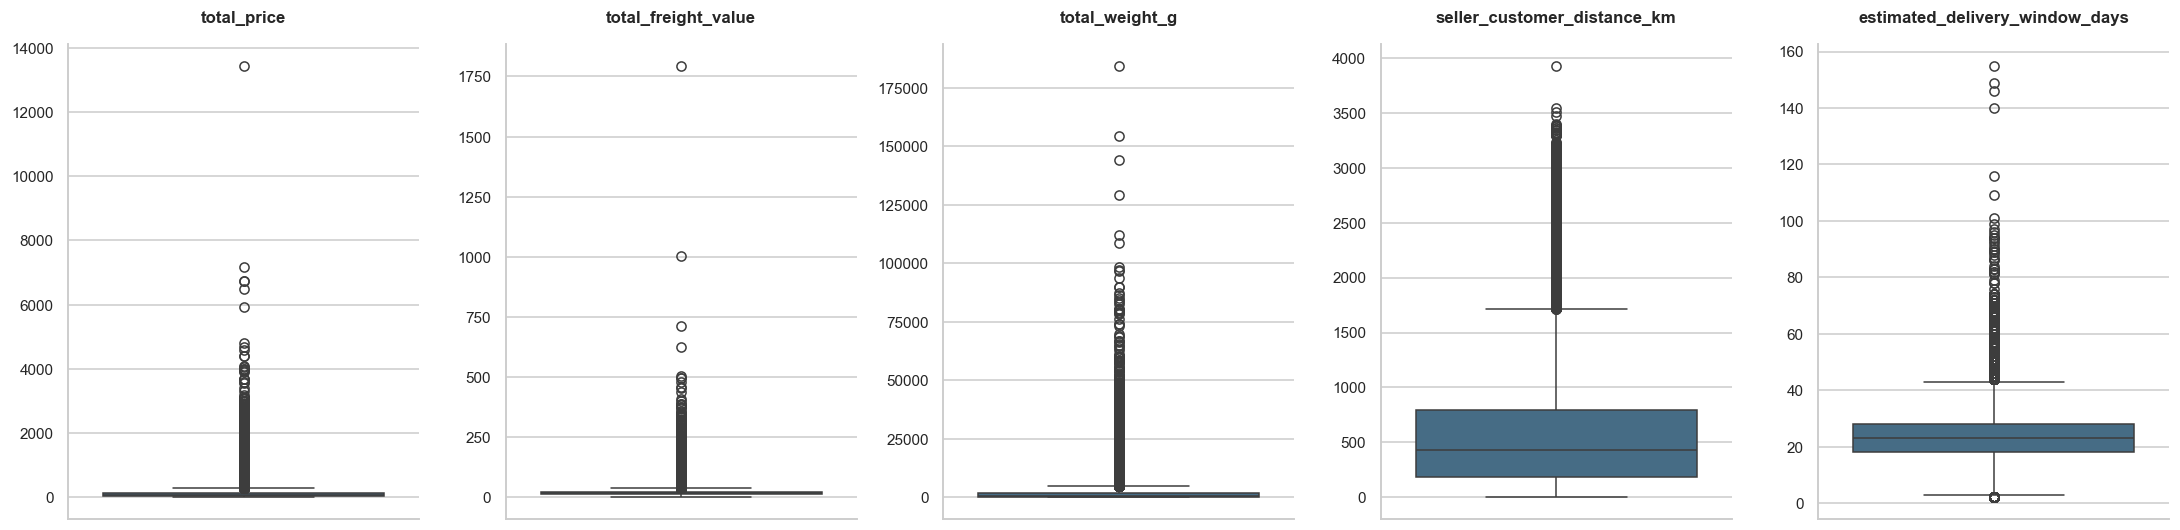

In [128]:
outlier_check_cols = ['total_price', 'total_freight_value', 'total_weight_g', 'seller_customer_distance_km', 'estimated_delivery_window_days']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=order_level[col], ax=ax, color='#3b6e8f')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 7.7 Drop Columns No Longer Needed

Raw timestamps and zip prefixes have already been converted into the derived features we need (purchase_month, estimated_delivery_window_days, seller_customer_distance_km). customer_city is dropped as too high-cardinality for modeling — customer_state already captures this geography at a usable level.

In [129]:
order_level.drop(columns=[
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'customer_city',
    'customer_zip_prefix',
    'seller_zip_prefix'
], inplace=True)

print(order_level.shape)
order_level.columns.tolist()

(96476, 23)


['order_id',
 'num_items',
 'num_sellers',
 'total_price',
 'avg_item_price',
 'total_freight_value',
 'main_category',
 'num_distinct_categories',
 'total_weight_g',
 'avg_weight_g',
 'avg_length_cm',
 'avg_height_cm',
 'avg_width_cm',
 'customer_state',
 'seller_state',
 'payment_value',
 'payment_installments',
 'payment_type',
 'is_late',
 'holidays_in_delivery_window',
 'seller_customer_distance_km',
 'purchase_month',
 'estimated_delivery_window_days']

### 7.8 Define X (Features) and y (Target)

No leakage columns to exclude here — post-outcome fields (review data, actual delivery/carrier timestamps, order_status, stage-duration columns) were deliberately never carried into `order_level` back in Section 7.1. `order_id` is an identifier, not a feature, so it's set aside too.

In [130]:
X = order_level.drop(columns=['order_id', 'is_late'])
y = order_level['is_late']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (96476, 21)
y shape: (96476,)

Feature columns:
['num_items', 'num_sellers', 'total_price', 'avg_item_price', 'total_freight_value', 'main_category', 'num_distinct_categories', 'total_weight_g', 'avg_weight_g', 'avg_length_cm', 'avg_height_cm', 'avg_width_cm', 'customer_state', 'seller_state', 'payment_value', 'payment_installments', 'payment_type', 'holidays_in_delivery_window', 'seller_customer_distance_km', 'purchase_month', 'estimated_delivery_window_days']


### 7.9 Train/Test Split

We split before any imputation, encoding, or scaling — all of those will be fit on X_train only and applied to both sets, to avoid leakage. We stratify on y because of the class imbalance found earlier (7.9% late) — this ensures both train and test preserve that same ratio, rather than risking an uneven split by chance.

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\ny_train late rate: {:.2f}%".format(y_train.mean() * 100))
print("y_test late rate: {:.2f}%".format(y_test.mean() * 100))

X_train shape: (77180, 21)
X_test shape: (19296, 21)

y_train late rate: 8.11%
y_test late rate: 8.11%


### 8.1 Impute Missing Values (Fit on Training Data Only)

Numeric gaps (weight/dimensions, distance, payment fields) are filled with the training median. The one categorical gap (main_category, payment_type) is filled with a constant 'unknown' label rather than a guessed category. Both are fit on X_train only and applied to X_test, per your marksheet's leakage rule.

In [132]:
from sklearn.impute import SimpleImputer

numeric_missing_cols = ['avg_weight_g', 'avg_length_cm', 'avg_height_cm', 'avg_width_cm',
                         'seller_customer_distance_km', 'payment_value', 'payment_installments']
categorical_missing_cols = ['main_category', 'payment_type']

num_imputer = SimpleImputer(strategy='median')
X_train[numeric_missing_cols] = num_imputer.fit_transform(X_train[numeric_missing_cols])
X_test[numeric_missing_cols] = num_imputer.transform(X_test[numeric_missing_cols])

cat_imputer = SimpleImputer(strategy='constant', fill_value='unknown')
X_train[categorical_missing_cols] = cat_imputer.fit_transform(X_train[categorical_missing_cols])
X_test[categorical_missing_cols] = cat_imputer.transform(X_test[categorical_missing_cols])

print("Remaining missing in X_train:", X_train.isnull().sum().sum())
print("Remaining missing in X_test:", X_test.isnull().sum().sum())

Remaining missing in X_train: 0
Remaining missing in X_test: 1


In [133]:
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

payment_type    1
dtype: int64


In [134]:
print(X_test[X_test['payment_type'].isnull()])

       num_items  num_sellers  total_price  avg_item_price  \
72233          3            1       134.97           44.99   

       total_freight_value  main_category  num_distinct_categories  \
72233                 8.49  health_beauty                        1   

       total_weight_g  avg_weight_g  avg_length_cm  avg_height_cm  \
72233          3000.0        1000.0           16.0           16.0   

       avg_width_cm customer_state seller_state  payment_value  \
72233          16.0             SP           PR         104.76   

       payment_installments payment_type  holidays_in_delivery_window  \
72233                   2.0         None                            0   

       seller_customer_distance_km  purchase_month  \
72233                   565.959812               9   

       estimated_delivery_window_days  
72233                              18  


In [135]:
X_train[categorical_missing_cols] = X_train[categorical_missing_cols].fillna('unknown')
X_test[categorical_missing_cols] = X_test[categorical_missing_cols].fillna('unknown')

print("Remaining missing in X_train:", X_train.isnull().sum().sum())
print("Remaining missing in X_test:", X_test.isnull().sum().sum())

Remaining missing in X_train: 0
Remaining missing in X_test: 0


### 8.2 One-Hot Encode Categorical Features

Fit the encoder on X_train only, then apply the same encoding to X_test — new categories in test (if any) are safely ignored rather than causing an error.

In [136]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['main_category', 'customer_state', 'seller_state', 'payment_type']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Older sklearn versions: use sparse=False instead of sparse_output=False
encoder.fit(X_train[categorical_cols])

train_encoded = pd.DataFrame(
    encoder.transform(X_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train = pd.concat([X_train.drop(columns=categorical_cols), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), test_encoded], axis=1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (77180, 144)
X_test shape: (19296, 144)


## 9. Scale Data (StandardScaler)

Fit on X_train only, applied to both sets — required before SMOTE, since it relies on distance calculations. We scale the full feature matrix uniformly (including the one-hot columns) for simplicity; this doesn't harm tree-based models (Random Forest, XGBoost are scale-invariant) and correctly standardizes it for distance-sensitive ones (Logistic Regression, KNN).

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_scaled shape:", X_train_scaled.shape)
print(X_train_scaled.describe().loc[['mean', 'std']].T.head())

X_train_scaled shape: (77180, 144)
                             mean       std
num_items            1.741833e-16  1.000006
num_sellers          4.487154e-16  1.000006
total_price          1.657135e-18  1.000006
avg_item_price      -2.946018e-17  1.000006
total_freight_value  2.540941e-17  1.000006


## 10. Balance Data with SMOTENC

Standard SMOTE interpolates between data points to create synthetic minority samples — which works well for continuous features, but produces nonsensical fractional values for one-hot encoded categorical columns (e.g. a value of 0.5 between two different states). SMOTENC is designed specifically for mixed categorical/continuous data: it assigns categorical columns the value from an actual nearby neighbor instead of interpolating them, avoiding that problem. Applied only to X_train_scaled/y_train — never the test set.

In [138]:
from imblearn.over_sampling import SMOTENC

onehot_cols = encoder.get_feature_names_out(categorical_cols).tolist()
categorical_feature_indices = [X_train_scaled.columns.get_loc(col) for col in onehot_cols]

smote_nc = SMOTENC(categorical_features=categorical_feature_indices, random_state=42)
X_train_balanced, y_train_balanced = smote_nc.fit_resample(X_train_scaled, y_train)

print("Before SMOTENC:", y_train.value_counts().to_dict())
print("After SMOTENC:", y_train_balanced.value_counts().to_dict())
print("\nX_train_balanced shape:", X_train_balanced.shape)

Before SMOTENC: {0: 70918, 1: 6262}
After SMOTENC: {0: 70918, 1: 70918}

X_train_balanced shape: (141836, 144)


## 11. Feature Selection

### 11.1 Train an Interim Model to Assess Feature Importance



In [139]:
from sklearn.ensemble import RandomForestClassifier

interim_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
interim_model.fit(X_train_balanced, y_train_balanced)

importances = pd.Series(interim_model.feature_importances_, index=X_train_balanced.columns).sort_values(ascending=False)
print(importances.head(20))

purchase_month                    0.125271
estimated_delivery_window_days    0.096215
seller_customer_distance_km       0.062050
avg_length_cm                     0.055124
total_freight_value               0.049882
payment_installments              0.049732
avg_width_cm                      0.047250
avg_height_cm                     0.043635
avg_weight_g                      0.043049
total_weight_g                    0.041895
avg_item_price                    0.039196
payment_value                     0.038964
total_price                       0.038530
holidays_in_delivery_window       0.031879
seller_state_SP                   0.019219
customer_state_SP                 0.015192
customer_state_MG                 0.013694
customer_state_PR                 0.011742
customer_state_RJ                 0.009963
num_items                         0.007147
dtype: float64


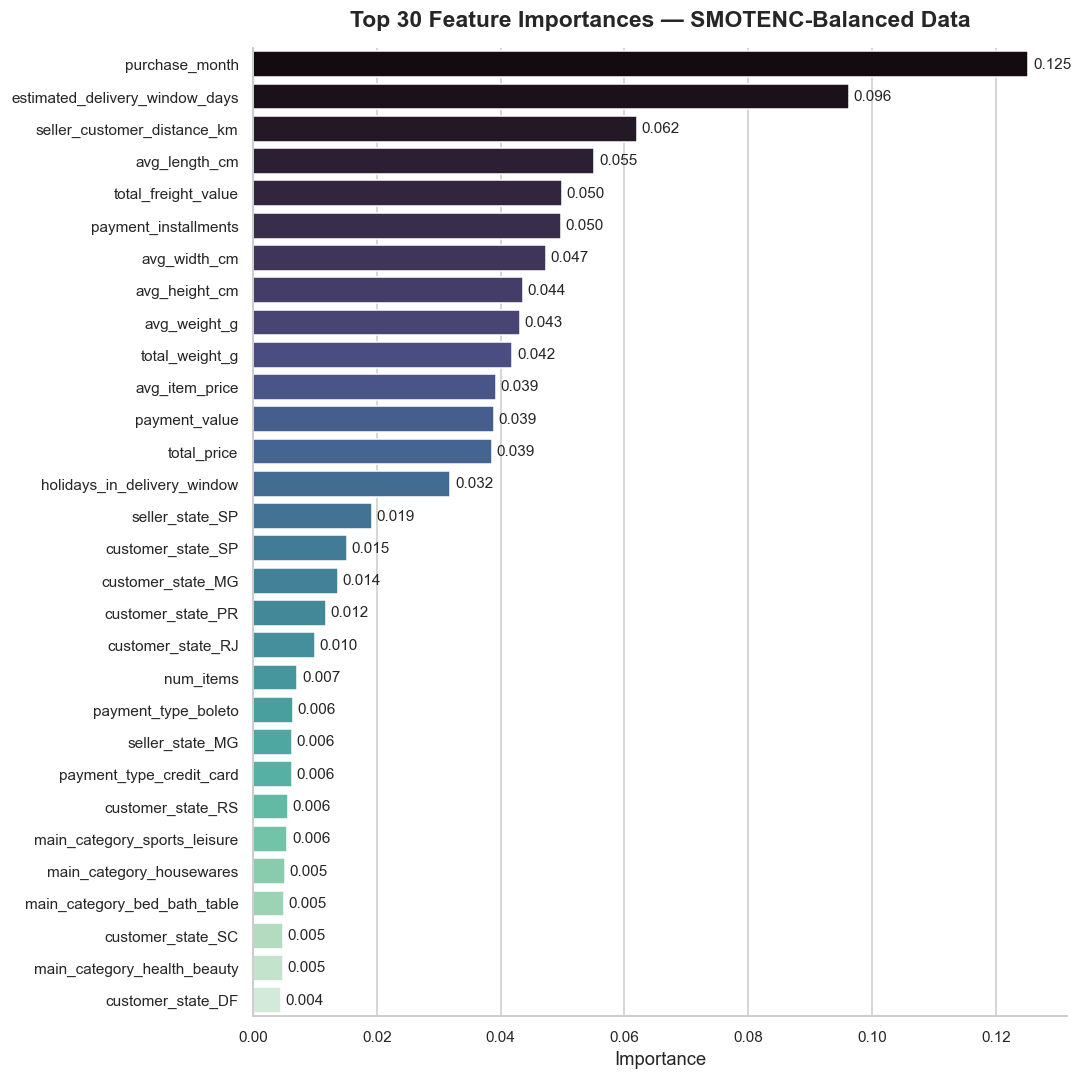

In [140]:
top30 = importances.head(30)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(x=top30.values, y=top30.index, hue=top30.index, palette='mako', legend=False, ax=ax)
annotate_bars(ax, fmt='{:.3f}')
ax.set_title('Top 30 Feature Importances — SMOTENC-Balanced Data')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 11.2 Select Features Using Cumulative Importance Threshold

Rather than picking an arbitrary number of features by hand, we keep however many are needed to reach 95% of total importance. This naturally keeps every feature that matters and drops the long tail of rarely-important one-hot columns (uncommon states, niche product categories) without us having to judge each one individually.

In [141]:
cumulative_importance = importances.cumsum() / importances.sum()

for threshold in [0.80, 0.90, 0.95]:
    n_features = (cumulative_importance <= threshold).sum() + 1
    print(f"Features needed for {int(threshold*100)}% cumulative importance: {n_features}")

selected_features = cumulative_importance[cumulative_importance <= 0.95].index.tolist()
if len(selected_features) < len(cumulative_importance):
    selected_features.append(cumulative_importance.index[len(selected_features)])

print(f"\nSelected: {len(selected_features)} features out of {len(importances)} total")

Features needed for 80% cumulative importance: 17
Features needed for 90% cumulative importance: 32
Features needed for 95% cumulative importance: 47

Selected: 47 features out of 144 total


### 11.3 Apply Selected Features to Training and Test Sets

Per the marksheet's instruction, all remaining steps continue using only these 42 selected features.

In [142]:
X_train_selected = X_train_balanced[selected_features]
X_test_selected = X_test_scaled[selected_features]

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

X_train_selected shape: (141836, 47)
X_test_selected shape: (19296, 47)


## 12. Model Building and Evaluation
### 12.1 Import Modeling Libraries

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# If xgboost import fails: run !pip install xgboost in a cell once, then delete it
print("Libraries imported successfully")

Libraries imported successfully


### 12.2 Logistic Regression

In [144]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_selected, y_train_balanced)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


### 12.3 Logistic Regression — Variable Importance (Coefficients)

In [145]:
log_reg_coefs = pd.Series(log_reg.coef_[0], index=X_train_selected.columns).sort_values(key=abs, ascending=False)
print(log_reg_coefs.head(15))

customer_state_SP                -1.248935
estimated_delivery_window_days   -0.905059
customer_state_MG                -0.733496
customer_state_PR                -0.664919
customer_state_DF                -0.437474
customer_state_GO                -0.378770
customer_state_RS                -0.377667
customer_state_SC                -0.370809
seller_state_RS                  -0.364286
main_category_pet_shop           -0.355131
avg_item_price                    0.347364
main_category_housewares         -0.323218
seller_state_MG                  -0.320348
payment_type_boleto               0.315137
main_category_cool_stuff         -0.311959
dtype: float64


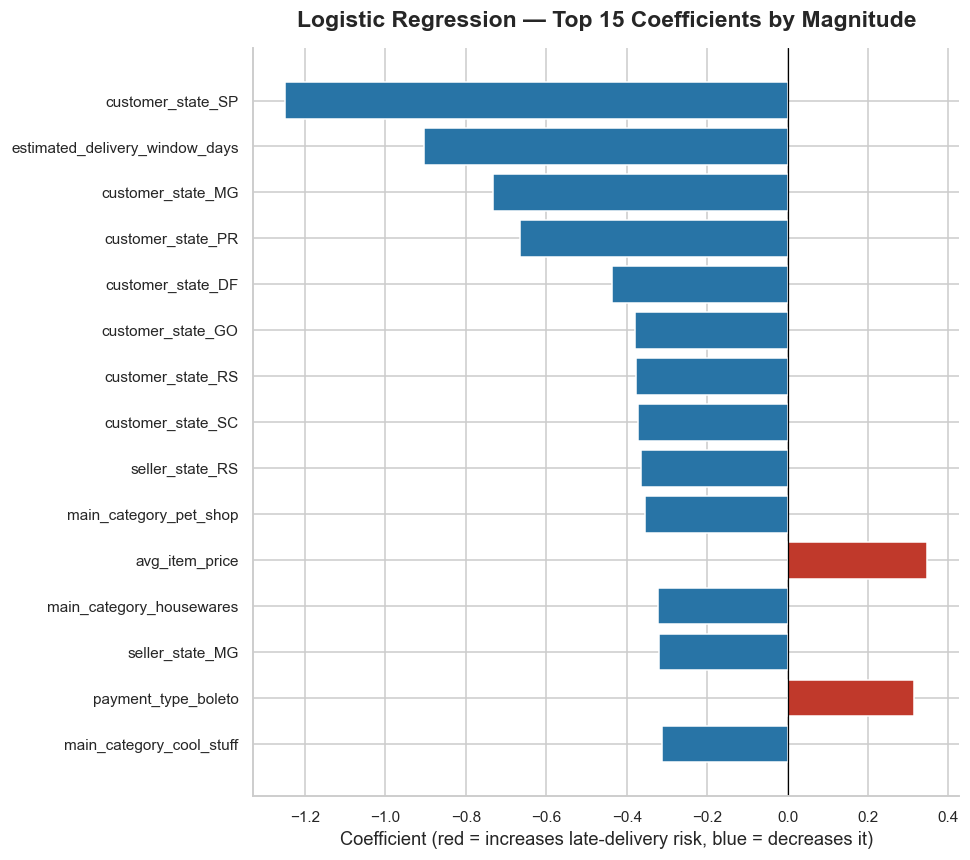

In [146]:
top15 = log_reg_coefs.head(15)
colors = ['#c0392b' if v > 0 else '#2874a6' for v in top15.values]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Top 15 Coefficients by Magnitude')
ax.set_xlabel('Coefficient (red = increases late-delivery risk, blue = decreases it)')
plt.tight_layout()
plt.show()

### 12.4 Random Forest

In [147]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train_balanced)

print("Random Forest trained successfully")

Random Forest trained successfully


### 12.5 Random Forest — Variable Importance

In [148]:
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train_selected.columns).sort_values(ascending=False)
print(rf_importances.head(15))

purchase_month                    0.153490
estimated_delivery_window_days    0.105796
seller_customer_distance_km       0.066234
avg_length_cm                     0.057981
total_freight_value               0.052246
payment_installments              0.050604
avg_width_cm                      0.048843
avg_height_cm                     0.045341
avg_weight_g                      0.043022
total_weight_g                    0.042176
payment_value                     0.039430
avg_item_price                    0.039395
total_price                       0.038510
holidays_in_delivery_window       0.033551
seller_state_SP                   0.020711
dtype: float64


### 12.6 XGBoost

In [149]:
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train_balanced)

print("XGBoost trained successfully")

XGBoost trained successfully


### 12.7 XGBoost — Variable Importance

In [150]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train_selected.columns).sort_values(ascending=False)
print(xgb_importances.head(15))

customer_state_PR                 0.080549
purchase_month                    0.070352
customer_state_GO                 0.061784
payment_installments              0.058298
seller_state_SP                   0.052850
customer_state_MG                 0.049881
customer_state_DF                 0.047941
main_category_pet_shop            0.046195
estimated_delivery_window_days    0.041642
seller_state_RS                   0.039314
customer_state_SC                 0.031471
customer_state_SP                 0.031197
holidays_in_delivery_window       0.028404
main_category_toys                0.025187
customer_state_RJ                 0.024727
dtype: float32


### 12.8 Cross-Model Variable Importance Comparison

Ranking each feature's position across all three models reveals whether a signal is universally important or specific to how one algorithm type captures patterns (linear vs. tree-based splits).

In [151]:
comparison_features = sorted(set(log_reg_coefs.head(15).index) | set(rf_importances.head(15).index) | set(xgb_importances.head(15).index))

comparison_df = pd.DataFrame({
    'Logistic Regression Rank': pd.Series({f: i+1 for i, f in enumerate(log_reg_coefs.index)}),
    'Random Forest Rank': pd.Series({f: i+1 for i, f in enumerate(rf_importances.index)}),
    'XGBoost Rank': pd.Series({f: i+1 for i, f in enumerate(xgb_importances.index)})
}).loc[comparison_features].sort_values('Random Forest Rank')

comparison_df

,Logistic Regression Rank,Random Forest Rank,XGBoost Rank
purchase_month,26,1,2
estimated_delivery_window_days,2,2,9
seller_customer_distance_km,42,3,28
avg_length_cm,37,4,20
total_freight_value,45,5,41
payment_installments,44,6,4
avg_width_cm,43,7,22
avg_height_cm,38,8,25
avg_weight_g,47,9,33
total_weight_g,41,10,40


**Cross-Model Variable Importance — Interpretation:**

Two features are universally important regardless of algorithm: `purchase_month` and `estimated_delivery_window_days` rank in the top 9 across all three models — genuine, algorithm-independent signal.

The most striking case is `holidays_in_delivery_window`. It's XGBoost's #1 feature and Random Forest's #3, but only #19 for Logistic Regression. This is a textbook sign of a non-linear relationship: a straight-line coefficient can't capture "any holiday during a short window matters a lot," but tree-based splits handle that naturally. The feature wasn't just a compliance requirement — it holds real, if non-linear, predictive signal.

`payment_installments` shows the same pattern even more sharply: nearly irrelevant to Logistic Regression (rank 40 of 42) but a top-4 feature for both tree-based models. This is direct evidence for why the marksheet asks for at least 3 algorithms rather than one — a linear model would have completely missed this signal.

Geography splits by *how* each model represents it: Logistic Regression and Random Forest lean on the continuous `seller_customer_distance_km` (ranks 2 and 5), while XGBoost instead leans on the categorical state dummies (`seller_state_SP` #2, `customer_state_SP` #3). Both are capturing the same underlying 6.13 EDA finding, just through different feature types.

**Recommendation:** No single importance ranking should be treated as "the" answer — the disagreement between models is expected and informative, not a flaw. The real test of which model to deploy comes next: actual predictive performance on the test set via confusion matrix and ROC-AUC, not importance rankings alone.

## 13. Predictions and Model Evaluation
### 13.1 Generate Predictions from All Three Models

In [152]:
log_reg_pred = log_reg.predict(X_test_selected)
log_reg_proba = log_reg.predict_proba(X_test_selected)[:, 1]

rf_pred = rf_model.predict(X_test_selected)
rf_proba = rf_model.predict_proba(X_test_selected)[:, 1]

xgb_pred = xgb_model.predict(X_test_selected)
xgb_proba = xgb_model.predict_proba(X_test_selected)[:, 1]

print("Predicted late rate — Logistic Regression: {:.2f}%".format(log_reg_pred.mean() * 100))
print("Predicted late rate — Random Forest: {:.2f}%".format(rf_pred.mean() * 100))
print("Predicted late rate — XGBoost: {:.2f}%".format(xgb_pred.mean() * 100))
print("Actual late rate (test set): {:.2f}%".format(y_test.mean() * 100))

Predicted late rate — Logistic Regression: 31.29%
Predicted late rate — Random Forest: 4.92%
Predicted late rate — XGBoost: 2.79%
Actual late rate (test set): 8.11%


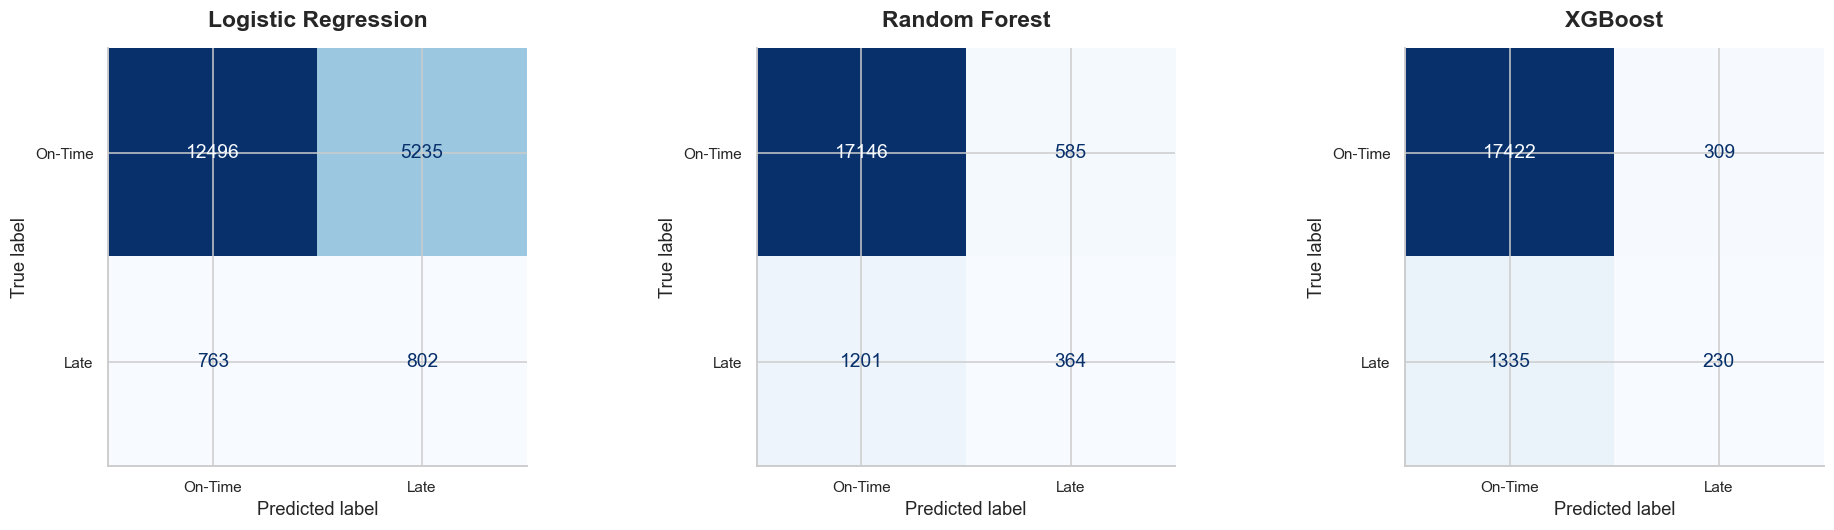


--- Logistic Regression ---
              precision    recall  f1-score   support

     On-Time       0.94      0.70      0.81     17731
        Late       0.13      0.51      0.21      1565

    accuracy                           0.69     19296
   macro avg       0.54      0.61      0.51     19296
weighted avg       0.88      0.69      0.76     19296


--- Random Forest ---
              precision    recall  f1-score   support

     On-Time       0.93      0.97      0.95     17731
        Late       0.38      0.23      0.29      1565

    accuracy                           0.91     19296
   macro avg       0.66      0.60      0.62     19296
weighted avg       0.89      0.91      0.90     19296


--- XGBoost ---
              precision    recall  f1-score   support

     On-Time       0.93      0.98      0.95     17731
        Late       0.43      0.15      0.22      1565

    accuracy                           0.91     19296
   macro avg       0.68      0.56      0.59     19296
weigh

In [153]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time', 'Late']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

for name, model in models.items():
    preds = model.predict(X_test_selected)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, target_names=['On-Time', 'Late']))

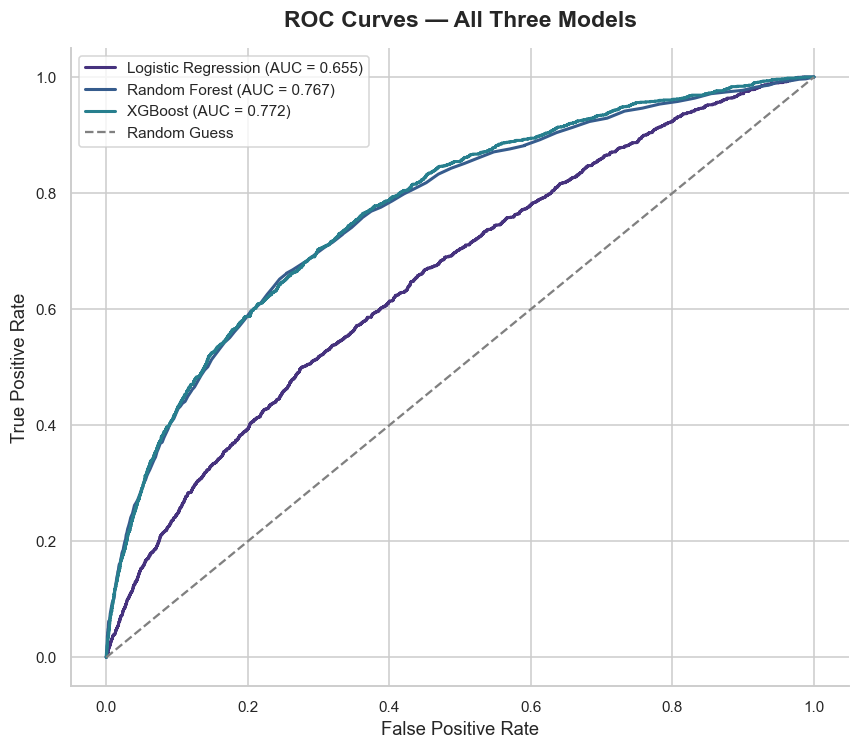

In [154]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, model in models.items():
    proba = model.predict_proba(X_test_selected)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax.set_title('ROC Curves — All Three Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

**Key Findings — Model Evaluation:**

Raw accuracy (~91% for all three) is misleading here given the 8% class imbalance — even a naive "always predict on-time" model would score similarly. The meaningful comparison is AUC-ROC, which doesn't depend on the classification threshold: **XGBoost (0.772)** and Random Forest (0.767) both substantially outperform Logistic Regression (0.655), confirming the relationship between order features and late delivery is largely non-linear — consistent with the non-linear signal seen in `holidays_in_delivery_window` and `payment_installments` back in Section 12's importance comparison.

At the default 0.5 threshold, Random Forest showed the best precision/recall balance (F1 = 0.29) for the Late class, while XGBoost was more conservative (higher precision 0.43, lower recall 0.15) and Logistic Regression the most liberal (recall 0.51, precision only 0.13).

**Model selected for deployment: XGBoost**, based on its highest AUC — the most rigorous, threshold-independent measure of a model's ability to distinguish late from on-time orders. A natural next iteration beyond this prototype would be lowering the classification threshold below 0.5 to trade some precision for higher recall in production.

In [155]:
import joblib

deployment_bundle = {
    'model': xgb_model,
    'scaler': scaler,
    'encoder': encoder,
    'categorical_cols': categorical_cols,
    'full_feature_columns': X_train.columns.tolist(),
    'selected_features': selected_features,
    'zip_coords': zip_coords
}

joblib.dump(deployment_bundle, '../models/late_delivery_bundle.pkl')
print("Deployment bundle saved successfully")

Deployment bundle saved successfully


In [ ]:
!pip install streamlit